<a href="https://colab.research.google.com/github/antoniovfonseca/compare-time-series/blob/main/notebooks/comparisonTimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Compare two time series of maps**

---

This notebook implements the analytical framework proposed by Pontius Jr. et al. to systematically compare two time series of raster maps, Time Series X and Time Series Y. The main goal is to transparently quantify and map the agreements and differences between the maps across space and time.

The analysis partitions the comparison into detailed components that answer specific geographic and temporal questions. The workflow is divided into three main methodological steps:

### 1. Presence Assessment
Evaluates the agreement concerning the presence of a category at each time point. The framework decomposes the comparison into exact components of agreement and difference:
*   **Hits:** Where both time series agree concerning the presence.
*   **False Alarms:** Where Time Series Y shows more presence than Time Series X at a specific time point.
*   **Misses:** Where Time Series X shows more presence than Time Series Y at a specific time point.
*   **Space Difference:** Where both time series agree on the total quantity of presence but disagree on its spatial location at a time point.
*   **Time Difference:** Where both time series agree on the location and quantity across the series but disagree on the specific time points.

### 2. Change Assessment
Analyzes the landscape dynamics by comparing the individual time intervals with the overall change during the temporal extent. This step evaluates landscape transformations by accounting for:
*   **Gross Gain and Gross Loss:** The magnitude of gross gains and gross losses.
*   **Net Change:** The net change, consolidating gains and losses.

### 3. Spatial Maps
In addition to the diverging stacked bar charts that summarize the affected areas, the notebook collapses the temporal dimension to generate pixel-by-pixel geographic visualizations:
*   **Hits Maps:** Maps the locations of consistent agreement between the time series throughout the time points.
*   **Difference Maps:** Reveals areas with systematic overestimation of the magnitude of presence or change, showing which time series shows more presence or more change.
*   **Temporal Allocation Maps:** Highlights the exact areas where the two time series agree on the total quantity of accumulated presence or change, but disagree exclusively on when these events occurred.

---
**Generated Outputs:** The notebook processes large raster data efficiently using windowed reading and exports analytical .csv tables, stacked bar charts, and .tif raster maps ready for ecological and spatial interpretation.



## **1. Environment Setup (Admin only)**

In [1]:
# @title 1.1 Install Dependencies
get_ipython().system('pip -q install matplotlib-scalebar matplotlib-map-utils')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 126.5 MB/s eta 0:00:00


In [10]:
# @title 1.2 Import Modules

# --- Standard Library Imports ---
import gc
import os
import re
from contextlib import ExitStack
from typing import Dict, List, Tuple, Union

# --- Google Colab Imports ---
from google.colab import drive

# --- Third-party Data & Geospatial Imports ---
import numpy as np
import pandas as pd
import rasterio
from pyproj import CRS, Geod, Transformer
from rasterio.windows import Window
from tqdm.auto import tqdm

# --- Matplotlib & Visualization Imports ---
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap, Normalize
from matplotlib.patches import FancyArrowPatch, Patch, Rectangle
from matplotlib.ticker import FuncFormatter
from matplotlib_map_utils import north_arrow
from matplotlib_scalebar.scalebar import ScaleBar

In [11]:
# @title 1.3 Mount Google Drive
# @markdown Run this cell only if your data are in Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **2. Input your data (User)**

In [4]:
# @title 2.1 Configure Your App { display-mode: "form" }
# @markdown ### 📂 Path Settings
# @markdown Folder containing the Time Series X raster files:
X_FOLDER_PATH = "/content/drive/MyDrive/Dataset/pie/pixel-based/extent" #@param {type:"string"}
# @markdown Folder containing the Time Series Y raster files:
Y_FOLDER_PATH = "/content/drive/MyDrive/Dataset/pie/object-based/extent" #@param {type:"string"}
# @markdown Output folder for tables, charts, and maps:
OUTPUT_PATH = "/content/drive/MyDrive/Assessments/compare-time-series/extent2" #@param {type:"string"}

# @markdown ### 🗓️ Time Range
# @markdown Comma-separated years in chronological order:
YEARS = "2010, 2012, 2014, 2016, 2018, 2021" #@param {type:"string"}

# @markdown ### 🧭 Raster Settings
NO_DATA_VALUE = 255 #@param {type:"integer"}
PRESENCE_VALUE = 1 #@param {type:"integer"}
ABSENCE_VALUE = 0 #@param {type:"integer"}

# @markdown ### 🏷️ File Names
X_FILE_PREFIX = "PIELTER_PB_" #@param {type:"string"}
Y_FILE_PREFIX = "PIELTER_OB_" #@param {type:"string"}
FILE_SUFFIX = ".tif" #@param {type:"string"}

# Build the paths consumed by the assessment cells.
years = [int(year.strip()) for year in YEARS.split(",") if year.strip()]
if not years:
    raise ValueError("Please provide at least one year in YEARS.")
if years != sorted(set(years)):
    raise ValueError("YEARS must be unique and in chronological order.")

time_series_x = [
    os.path.join(X_FOLDER_PATH, f"{X_FILE_PREFIX}{year}{FILE_SUFFIX}")
    for year in years
]
time_series_y = [
    os.path.join(Y_FOLDER_PATH, f"{Y_FILE_PREFIX}{year}{FILE_SUFFIX}")
    for year in years
]

no_data_value = NO_DATA_VALUE
presence_value = PRESENCE_VALUE
absence_value = ABSENCE_VALUE
output_path = OUTPUT_PATH

# Validate folders and files immediately.
missing_paths = [
    path for path in [X_FOLDER_PATH, Y_FOLDER_PATH, OUTPUT_PATH]
    if not os.path.exists(path)
]
missing_files = [
    path for path in time_series_x + time_series_y
    if not os.path.isfile(path)
]

if missing_paths or missing_files:
    print("❌ Configuration needs attention.")
    if missing_paths:
        print("Missing folders:")
        for path in missing_paths:
            print(f"  - {path}")
    if missing_files:
        print("Missing raster files:")
        for path in missing_files:
            print(f"  - {path}")
else:
    print(f"✅ Ready to process {len(years)} years of maps.")

✅ Ready to process 6 years of maps.


## **3.Presence Assessment**

In [ ]:
# @title 3.1 Presence Assessment Functions
def compute_presence_metrics_block(
    array_x: np.ndarray,
    array_y: np.ndarray,
    no_data_val: int,
    presence_val: int
) -> Dict[str, int]:
    """
    Computes essential presence metrics using optimized boolean logic.

    Reduces memory overhead by using binary masks instead of multiple
    integer arrays. Only calculates hits and totals as these are
    the necessary scalars for Pontius Jr. et al. equations.

    Parameters
    ----------
    array_x : np.ndarray
        Data array from Time Series X.
    array_y : np.ndarray
        Data array from Time Series Y.
    no_data_val : int
        Pixel value indicating no data.
    presence_val : int
        Pixel value indicating presence.

    Returns
    -------
    Dict[str, int]
        Aggregated counts (Hits, Sum X, Sum Y) for the window.
    """
    # 1. Create binary masks (Boolean arrays use significantly less RAM)
    mask_x = (array_x == presence_val)
    mask_y = (array_y == presence_val)

    # 2. Identify valid pixels (exclude no-data values)
    valid_mask = (array_x != no_data_val) & (array_y != no_data_val)

    # 3. Fast scalar count using logical bitwise intersection
    # np.count_nonzero is faster than np.sum for boolean masks
    hits_count = int(
        np.count_nonzero(
            mask_x & mask_y & valid_mask
        )
    )

    sum_x_count = int(
        np.count_nonzero(
            mask_x & valid_mask
        )
    )

    sum_y_count = int(
        np.count_nonzero(
            mask_y & valid_mask
        )
    )

    # Returning 5 keys for compatibility, although the last two are
    # redundant in this optimized workflow.
    return {
        "hits_sum": hits_count,
        "fa_sum": 0, # Placeholder, calculated at the year-level for speed
        "misses_sum": 0, # Placeholder
        "x_sum": sum_x_count,
        "y_sum": sum_y_count
    }


def calculate_presence_assessment(
    ts_x_paths: List[str],
    ts_y_paths: List[str],
    no_data_val: int = 255,
    presence_val: int = 1,
    output_csv: str = "presence_assessment_metrics.csv"
) -> pd.DataFrame:
    """
    Executes Presence Assessment with optimized logic and identical UI structure.

    Parameters
    ----------
    ts_x_paths : List[str]
        Paths to Time Series X.
    ts_y_paths : List[str]
        Paths to Time Series Y.
    no_data_val : int, optional
        Value for invalid pixels. Default is 255.
    presence_val : int, optional
        Value for presence. Default is 1.
    output_csv : str, optional
        Path for the exported CSV.

    Returns
    -------
    pd.DataFrame
        DataFrame with per-year and total metrics.
    """
    results = []

    # Overall accumulators
    total_hits = 0
    total_sum_x = 0
    total_sum_y = 0
    total_space_diff = 0

    # UI: Using the exact tqdm structure you provided
    for idx, (x_path, y_path) in enumerate(
        tqdm(
            zip(ts_x_paths, ts_y_paths),
            total=len(ts_x_paths),
            desc="Presence Assessment"
        )
    ):
        # Extract year label
        match = re.search(r'\d{4}', x_path)
        year_label = match.group(0) if match else f"Time_{idx+1}"

        yr_hits = 0
        yr_sum_x = 0
        yr_sum_y = 0

        # Efficient windowed reading
        with rasterio.open(x_path) as src_x, \
             rasterio.open(y_path) as src_y:

            for _, window in src_x.block_windows():
                arr_x = src_x.read(1, window=window)
                arr_y = src_y.read(1, window=window)

                metrics = compute_presence_metrics_block(
                    arr_x,
                    arr_y,
                    no_data_val,
                    presence_val
                )

                yr_hits += metrics["hits_sum"]
                yr_sum_x += metrics["x_sum"]
                yr_sum_y += metrics["y_sum"]

        # Equation calculations (Calculated once per time point for speed)
        # Eq 5: Space Difference (Pu)
        yr_space_diff = min(yr_sum_x, yr_sum_y) - yr_hits

        # Eq 6 & 7: False Alarms and Misses (Quantity errors)
        yr_fa = max(0, yr_sum_y - yr_sum_x)
        yr_misses = max(0, yr_sum_x - yr_sum_y)

        results.append({
            "Year": year_label,
            "Hits": yr_hits,
            "False Alarms": yr_fa,
            "Misses": yr_misses,
            "Space Difference": yr_space_diff,
            "Time Difference": 0
        })

        # Update series totals
        total_hits += yr_hits
        total_sum_x += yr_sum_x
        total_sum_y += yr_sum_y
        total_space_diff += yr_space_diff

        # Cleanup RAM after each year
        gc.collect()

    # Overall Summary calculations
    overall_time_diff = min(total_sum_x, total_sum_y) - \
                        total_hits - total_space_diff

    total_fa = max(0, total_sum_y - total_sum_x)
    total_misses = max(0, total_sum_x - total_sum_y)

    results.append({
        "Year": "Total",
        "Hits": total_hits,
        "False Alarms": total_fa,
        "Misses": total_misses,
        "Space Difference": total_space_diff,
        "Time Difference": overall_time_diff
    })

    # Prepare final DataFrame and export
    df_metrics = pd.DataFrame(results)
    df_metrics.to_csv(output_csv, index=False)

    return df_metrics


# --- Execution block keeping your original setup ---
tables_dir = os.path.join(output_path, "tables")
os.makedirs(tables_dir, exist_ok=True)
csv_file_path = os.path.join(tables_dir, "presence_assessment_metrics.csv")

# UI: Original print statement restored
print(f"Executing Presence Assessment...\nSaving output to: {csv_file_path}\n")

df_presence_metrics = calculate_presence_assessment(
    ts_x_paths=time_series_x,
    ts_y_paths=time_series_y,
    no_data_val=no_data_value,
    presence_val=presence_value,
    output_csv=csv_file_path
)

# UI: Original display call restored
display(df_presence_metrics)

Executing Presence Assessment...
Saving output to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/tables/presence_assessment_metrics.csv



Presence Assessment:   0%|          | 0/6 [00:00<?, ?it/s]

,Year,Hits,False Alarms,Misses,Space Difference,Time Difference
0,2010,32833523,0,11293593,982000,0
1,2012,41488183,1690292,0,2066152,0
2,2014,49136790,2328742,0,1279935,0
3,2016,23570290,0,4216715,2267746,0
4,2018,41327597,0,492178,3750293,0
5,2021,43007553,0,1420851,3247063,0
6,Total,231363936,0,13404303,13593189,4019034


### 3.2 Plot Presence for each time point

Chart successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/charts/presence_assessment_chart.png



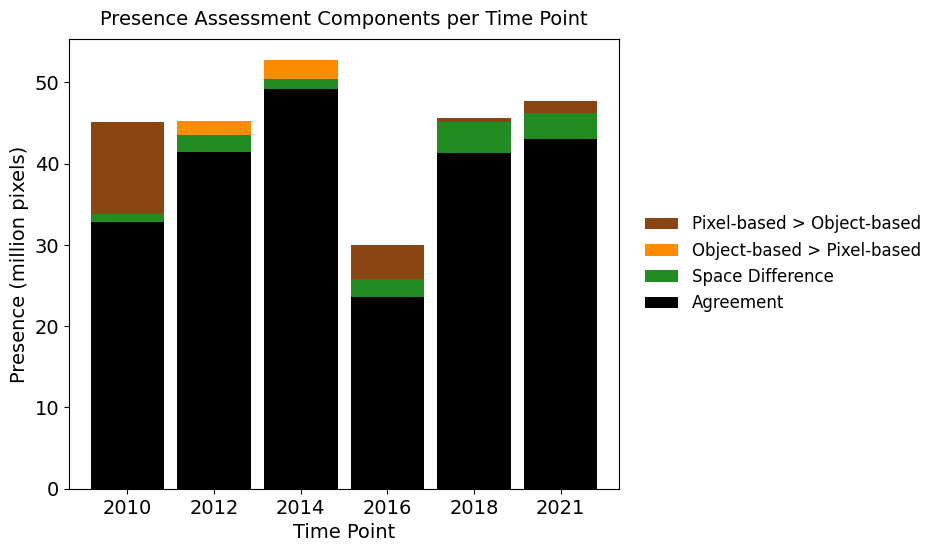

In [ ]:
# @title 3.2 Plotting Function
def plot_presence_assessment(
    csv_path: str,
    output_dir: str
) -> None:
    """
    Reads the presence assessment metrics CSV, prepares the data using
    optimized mapping, and generates a high-resolution stacked bar chart.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the presence assessment metrics.
    output_dir : str
        Directory where the 'charts' folder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Read and Prepare Data
    df = pd.read_csv(csv_path)

    # Filter out 'Total' and rename columns in a single flow
    # to avoid multiple intermediate copies of the dataframe
    mapping = {
        'Hits':             'Agreement',
        'False Alarms':     'Object-based > Pixel-based',
        'Misses':           'Pixel-based > Object-based',
        'Space Difference': 'Space Difference'
    }

    # Selection and indexing
    df_plot = df.loc[df['Year'] != 'Total'].copy()
    df_plot = df_plot.rename(columns=mapping).set_index('Year') # pyright: ignore[reportCallIssue]

    # Define the specific order of the stack (Bottom to Top)
    metrics_order = [
        'Agreement',
        'Space Difference',
        'Object-based > Pixel-based',
        'Pixel-based > Object-based'
    ]
    df_plot = df_plot[metrics_order]

    # 2. Optimized Dynamic Scaling Logic
    max_val = df_plot.sum(axis=1).max()

    # Scale lookup table to avoid redundant if-else chains
    scale_benchmarks = [
        (1e12, 1e12, "trillion"),
        (1e9, 1e9, "billion"),
        (1e6, 1e6, "million"),
        (1e3, 1e3, "thousand"),
        (100, 100, "hundred")
    ]

    scale_factor = 1
    unit_name = "pixels"

    for threshold, factor, label in scale_benchmarks:
        if max_val >= threshold:
            scale_factor = factor
            unit_name = f"{label} pixels"
            break

    y_label = f"Presence ({unit_name})"

    # Efficient vectorized scaling
    df_plot /= scale_factor

    # 3. Styling and Colors
    # Palette matches the user-defined accessible colors
    colors = [
        '#000000',  # Agreement
        '#228B22',  # Space Difference
        '#FF8C00',  # False Alarms
        '#8B4513'   # Misses
    ]

    # Initialize the Figure with fixed size and margins
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.15
    )

    # Generate Chart
    df_plot.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors,
        edgecolor='none',
        linewidth=0,
        width=0.85
    )

    # 4. Titles and Labels
    ax.set_title(
        'Presence Assessment Components per Time Point',
        fontsize=14,
        pad=10
    )
    ax.set_xlabel('Time Point', fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)

    # 5. Legend Customization
    handles, labels = ax.get_legend_handles_labels()

    # Desired order (Top to Bottom)
    desired_order = [
        'Pixel-based > Object-based',
        'Object-based > Pixel-based',
        'Space Difference',
        'Agreement'
    ]

    # Reordering handles based on user request
    order_dict = {
        label: idx for idx, label in enumerate(labels)
    }
    ordered_handles = [
        handles[order_dict[lbl]] for lbl in desired_order
    ]
    ordered_labels = [
        labels[order_dict[lbl]] for lbl in desired_order
    ]

    leg = ax.legend(
        ordered_handles,
        ordered_labels,
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        frameon=False,
        fontsize=12
    )

    # Aesthetic cleanup: remove symbol borders to keep layout clean
    for patch in leg.get_patches():
        patch.set_linewidth(0)
        patch.set_edgecolor('none')

    # Axis tick parameters
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=14
    )
    plt.xticks(rotation=0)

    # 6. Save and Display
    charts_dir = os.path.join(output_dir, "charts")
    os.makedirs(charts_dir, exist_ok=True)

    output_file = os.path.join(
        charts_dir,
        "presence_assessment_chart.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        format='png'
    )

    # Display message and the actual plot
    print(f"Chart successfully saved to: {output_file}\n")
    plt.show()

# --- Execute Execution ---
# Restoring the execution block and UI outputs
tables_dir = os.path.join(
    output_path,
    "tables"
)
csv_file_path = os.path.join(
    tables_dir,
    "presence_assessment_metrics.csv"
)

# Call the function
plot_presence_assessment(
    csv_file_path,
    output_path
)

### 3.3 Plot Sum chart

Chart successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/charts/presence_sum_chart.png



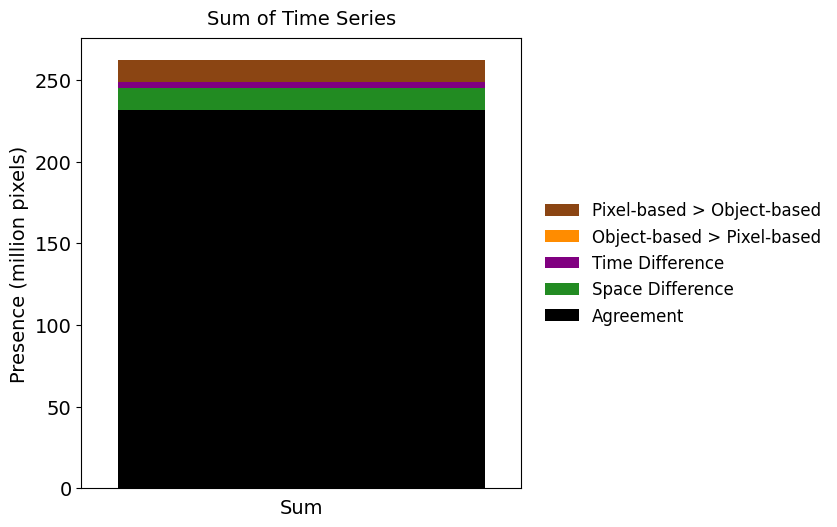

In [ ]:
# @title 3.3 Sum Chart Function
def plot_sum_chart(
    csv_path: str,
    output_dir: str
) -> None:
    """
    Reads the presence assessment metrics CSV, filters the 'Total' row,
    and generates a single optimized stacked bar chart representing
    the sum over time.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the presence assessment metrics.
    output_dir : str
        Directory where the 'charts' folder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Read and Prepare Data
    df = pd.read_csv(csv_path)

    # Isolate the 'Total' row and rename in a single operation
    mapping = {
        'Hits': 'Agreement',
        'False Alarms': 'Object-based > Pixel-based',
        'Misses': 'Pixel-based > Object-based'
    }

    df_plot = df.loc[df['Year'] == 'Total'].copy()
    df_plot = df_plot.rename(columns=mapping).set_index('Year') # pyright: ignore[reportCallIssue]

    # Define the specific order of the stack from bottom to top
    metrics_order = [
        'Agreement',
        'Space Difference',
        'Time Difference',
        'Object-based > Pixel-based',
        'Pixel-based > Object-based'
    ]
    df_plot = df_plot[metrics_order]

    # 2. Optimized Dynamic Scaling Logic
    max_val = df_plot.sum(axis=1).max()

    scale_benchmarks = [
        (1e12, 1e12, "trillion"),
        (1e9, 1e9, "billion"),
        (1e6, 1e6, "million"),
        (1e3, 1e3, "thousand"),
        (100, 100, "hundred")
    ]

    scale_factor = 1
    unit_name = "pixels"

    for threshold, factor, label in scale_benchmarks:
        if max_val >= threshold:
            scale_factor = factor
            unit_name = f"{label} pixels"
            break

    y_label = f"Presence ({unit_name})"

    # Efficient vectorized scaling
    df_plot /= scale_factor

    # 3. Styling and Colors
    colors = [
        '#000000',  # Agreement
        '#228B22',  # Space Difference
        '#800080',  # Time Difference
        '#FF8C00',  # False Alarms
        '#8B4513'   # Misses
    ]

    # Initialize Figure with specific margins
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.15
    )

    # Plot single stacked bar
    df_plot.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors,
        edgecolor='none',
        linewidth=0,
        width=1.0
    )

    # Remove empty space on the sides of the single bar
    ax.set_xlim(-0.6, 0.6)

    # 4. Titles and Labels
    ax.set_title(
        'Sum of Time Series',
        fontsize=14,
        pad=10
    )
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xlabel('')

    # Customize X-axis tick
    ax.set_xticklabels(
        ['Sum'],
        fontsize=14,
        rotation=0
    )
    ax.tick_params(bottom=False)

    # 5. Legend Customization
    handles, labels = ax.get_legend_handles_labels()

    # Requested order (Top to Bottom)
    desired_order = [
        'Pixel-based > Object-based',
        'Object-based > Pixel-based',
        'Time Difference',
        'Space Difference',
        'Agreement'
    ]

    order_dict = {label: idx for idx, label in enumerate(labels)}
    ordered_handles = [handles[order_dict[lbl]] for lbl in desired_order]
    ordered_labels = [labels[order_dict[lbl]] for lbl in desired_order]

    leg = ax.legend(
        ordered_handles,
        ordered_labels,
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        frameon=False,
        fontsize=12
    )

    # Aesthetic cleanup: remove symbol borders
    for patch in leg.get_patches():
        patch.set_linewidth(0)
        patch.set_edgecolor('none')

    ax.tick_params(
        axis='y',
        which='major',
        labelsize=14
    )

    # 6. Save and Display
    charts_dir = os.path.join(output_dir, "charts")
    os.makedirs(charts_dir, exist_ok=True)

    output_file = os.path.join(
        charts_dir,
        "presence_sum_chart.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        format='png'
    )

    print(f"Chart successfully saved to: {output_file}\n")
    plt.show()

# --- Execution ---
tables_dir = os.path.join(
    output_path,
    "tables"
)
csv_file_path = os.path.join(
    tables_dir,
    "presence_assessment_metrics.csv"
)

# Execute the refactored function
plot_sum_chart(
    csv_file_path,
    output_path
)

## **4.Change Assessment**

In [ ]:
# @title 4.1 Compute gross change
# 1. Optimized Computation Functions
def compute_change_block(
    arr_x0: np.ndarray,
    arr_x1: np.ndarray,
    arr_y0: np.ndarray,
    arr_y1: np.ndarray,
    no_data_val: int,
    presence_val: int,
) -> Dict[str, int]:
    """
    Computes fundamental change metrics for a spatial block using boolean logic.

    Uses bitwise operations to identify gains and losses, significantly
    reducing memory overhead compared to arithmetic methods.

    Parameters
    ----------
    arr_x0 : np.ndarray
        Array for Time Series X at time t-1.
    arr_x1 : np.ndarray
        Array for Time Series X at time t.
    arr_y0 : np.ndarray
        Array for Time Series Y at time t-1.
    arr_y1 : np.ndarray
        Array for Time Series Y at time t.
    no_data_val : int
        Pixel value indicating no data.
    presence_val : int
        Pixel value indicating presence.

    Returns
    -------
    Dict[str, int]
        Aggregated counts for Gain/Loss Hits and total counts for X and Y.
    """
    # Create binary masks (Booleans are memory efficient)
    mask_x0 = (arr_x0 == presence_val)
    mask_x1 = (arr_x1 == presence_val)
    mask_y0 = (arr_y0 == presence_val)
    mask_y1 = (arr_y1 == presence_val)

    # Valid pixels mask (must be valid in all four maps)
    valid = (
        (arr_x0 != no_data_val) &
        (arr_x1 != no_data_val) &
        (arr_y0 != no_data_val) &
        (arr_y1 != no_data_val)
    )

    # Detect Gains (0 to 1) and Losses (1 to 0) using bitwise logic
    gain_x = mask_x1 & ~mask_x0 & valid
    gain_y = mask_y1 & ~mask_y0 & valid
    loss_x = ~mask_x1 & mask_x0 & valid
    loss_y = ~mask_y1 & mask_y0 & valid

    # Fast scalar aggregation using np.count_nonzero
    return {
        "gh": int(np.count_nonzero(gain_x & gain_y)),
        "gx": int(np.count_nonzero(gain_x)),
        "gy": int(np.count_nonzero(gain_y)),
        "lh": int(np.count_nonzero(loss_x & loss_y)),
        "lx": int(np.count_nonzero(loss_x)),
        "ly": int(np.count_nonzero(loss_y)),
    }


# 2. Main Assessment Logic
def calculate_change_assessment(
    ts_x_paths: List[str],
    ts_y_paths: List[str],
    no_data_val: int = 255,
    presence_val: int = 1,
    output_csv: str = "change_assessment_metrics.csv",
) -> pd.DataFrame:
    """
    Executes the Change Assessment over geospatial time series with full
    progress tracking and optimized memory usage.

    Parameters
    ----------
    ts_x_paths : List[str]
        File paths to Time Series X.
    ts_y_paths : List[str]
        File paths to Time Series Y.
    no_data_val : int, optional
        Value for invalid pixels. Default is 255.
    presence_val : int, optional
        Value for presence. Default is 1.
    output_csv : str, optional
        File path for the output CSV. Default is 'change_assessment_metrics.csv'.

    Returns
    -------
    pd.DataFrame
        DataFrame containing interval-based and aggregated change metrics.
    """
    results = []

    # Summary accumulators for Total_Sum row
    total_gain_m = {
        "gh": 0,
        "gx": 0,
        "gy": 0,
    }
    total_loss_m = {
        "lh": 0,
        "lx": 0,
        "ly": 0,
    }
    acc_space_diff_gain = 0
    acc_space_diff_loss = 0

    num_intervals = len(ts_x_paths) - 1

    # Main progress bar for Time Intervals
    # total=num_intervals ensures visibility in VS Code
    pbar_intervals = tqdm(
        range(num_intervals),
        desc="1/2 Assessment Intervals",
    )

    for t in pbar_intervals:
        x0_p, x1_p = ts_x_paths[t], ts_x_paths[t + 1]
        y0_p, y1_p = ts_y_paths[t], ts_y_paths[t + 1]

        # Year label extraction for interval naming
        m1 = re.search(r"\d{4}", x1_p)
        m0 = re.search(r"\d{4}", x0_p)
        label = (
            f"{m0.group(0)}-{m1.group(0)}"
            if m1 and m0
            else f"Interval_{t + 1}"
        )

        int_m = {
            "gh": 0, "gx": 0, "gy": 0,
            "lh": 0, "lx": 0, "ly": 0,
        }

        # Windowed reading across four rasters simultaneously
        with rasterio.open(x0_p) as sx0, \
             rasterio.open(x1_p) as sx1, \
             rasterio.open(y0_p) as sy0, \
             rasterio.open(y1_p) as sy1:

            # Sub-progress bar for blocks/windows
            windows = list(sx0.block_windows())
            pbar_blocks = tqdm(
                windows,
                desc=f"   -> {label}",
                leave=False,
            )

            for _, window in pbar_blocks:
                block_m = compute_change_block(
                    sx0.read(1, window=window),
                    sx1.read(1, window=window),
                    sy0.read(1, window=window),
                    sy1.read(1, window=window),
                    no_data_val,
                    presence_val,
                )
                # Aggregate block results into interval counters
                for key in int_m:
                    int_m[key] += block_m[key]

        # Compute Pontius components for current interval
        gu = min(int_m["gx"], int_m["gy"]) - int_m["gh"]
        lu = min(int_m["lx"], int_m["ly"]) - int_m["lh"]

        results.append({
            "Time_Interval": label,
            "Change_Type": "Gain",
            "Hits": int_m["gh"],
            "False Alarms": max(0, int_m["gy"] - int_m["gx"]),
            "Misses": max(0, int_m["gx"] - int_m["gy"]),
            "Space Difference": gu,
            "Time Difference": 0,
            "Alternation": 0,
        })
        results.append({
            "Time_Interval": label,
            "Change_Type": "Loss",
            "Hits": int_m["lh"],
            "False Alarms": max(0, int_m["ly"] - int_m["lx"]),
            "Misses": max(0, int_m["lx"] - int_m["ly"]),
            "Space Difference": lu,
            "Time Difference": 0,
            "Alternation": 0,
        })

        # Update overall series summary metrics
        for k in total_gain_m:
            total_gain_m[k] += int_m[k]
        for k in total_loss_m:
            total_loss_m[k] += int_m[k]

        acc_space_diff_gain += gu
        acc_space_diff_loss += lu

        # Explicit garbage collection for raster buffers
        gc.collect()

    # Calculate Total_Sum row (Overall Time Difference)
    gv = (
        min(total_gain_m["gx"], total_gain_m["gy"]) -
        total_gain_m["gh"] -
        acc_space_diff_gain
    )
    lv = (
        min(total_loss_m["lx"], total_loss_m["ly"]) -
        total_loss_m["lh"] -
        acc_space_diff_loss
    )

    results.append({
        "Time_Interval": "Total_Sum",
        "Change_Type": "Gain",
        "Hits": total_gain_m["gh"],
        "False Alarms": max(0, total_gain_m["gy"] - total_gain_m["gx"]),
        "Misses": max(0, total_gain_m["gx"] - total_gain_m["gy"]),
        "Space Difference": acc_space_diff_gain,
        "Time Difference": gv,
        "Alternation": 0,
    })
    results.append({
        "Time_Interval": "Total_Sum",
        "Change_Type": "Loss",
        "Hits": total_loss_m["lh"],
        "False Alarms": max(0, total_loss_m["ly"] - total_loss_m["lx"]),
        "Misses": max(0, total_loss_m["lx"] - total_loss_m["ly"]),
        "Space Difference": acc_space_diff_loss,
        "Time Difference": lv,
        "Alternation": 0,
    })

    # Temporal Extent calculation (First map vs Last map)
    ext_m = {
        "gh": 0, "gx": 0, "gy": 0,
        "lh": 0, "lx": 0, "ly": 0,
    }
    with rasterio.open(ts_x_paths[0]) as sx0, \
         rasterio.open(ts_x_paths[-1]) as sx1, \
         rasterio.open(ts_y_paths[0]) as sy0, \
         rasterio.open(ts_y_paths[-1]) as sy1:

        ext_windows = list(sx0.block_windows())
        # Progress bar for the extent calculation
        pbar_ext = tqdm(
            ext_windows,
            desc="2/2 Temporal Extent",
        )

        for _, window in pbar_ext:
            block_m = compute_change_block(
                sx0.read(1, window=window),
                sx1.read(1, window=window),
                sy0.read(1, window=window),
                sy1.read(1, window=window),
                no_data_val,
                presence_val,
            )
            for k in ext_m:
                ext_m[k] += block_m[k]

    results.append({
        "Time_Interval": "Temporal_Extent",
        "Change_Type": "Gain",
        "Hits": ext_m["gh"],
        "False Alarms": max(0, ext_m["gy"] - ext_m["gx"]),
        "Misses": max(0, ext_m["gx"] - ext_m["gy"]),
        "Space Difference": min(ext_m["gx"], ext_m["gy"]) - ext_m["gh"],
        "Time Difference": 0,
        "Alternation": 0,
    })
    results.append({
        "Time_Interval": "Temporal_Extent",
        "Change_Type": "Loss",
        "Hits": ext_m["lh"],
        "False Alarms": max(0, ext_m["ly"] - ext_m["lx"]),
        "Misses": max(0, ext_m["lx"] - ext_m["ly"]),
        "Space Difference": min(ext_m["lx"], ext_m["ly"]) - ext_m["lh"],
        "Time Difference": 0,
        "Alternation": 0,
    })

    # Final logic for Alternation
    df = pd.DataFrame(results)
    metrics_cols = ["Hits", "False Alarms", "Misses", "Space Difference"]

    for c_type in ["Gain", "Loss"]:
        mask_tot = (df["Time_Interval"] == "Total_Sum") & (df["Change_Type"] == c_type)
        mask_ext = (df["Time_Interval"] == "Temporal_Extent") & (df["Change_Type"] == c_type)

        sum_tot = df.loc[mask_tot, metrics_cols].sum(axis=1).values[0]
        sum_ext = df.loc[mask_ext, metrics_cols].sum(axis=1).values[0]

        df.loc[mask_tot, "Alternation"] = sum_tot - sum_ext

    # Save to CSV
    df.to_csv(output_csv, index=False)

    # Explicit confirmation message
    print(f"Executing Change Assessment...\nCSV successfully saved to: {output_csv}\n")

    return df


# 3. Execution Logic
# Define output path structure
tables_dir = os.path.join(output_path, "tables")
os.makedirs(tables_dir, exist_ok=True)
change_csv_path = os.path.join(tables_dir, "change_assessment_metrics.csv")

# Execute assessment
df_change_metrics = calculate_change_assessment(
    ts_x_paths=time_series_x,
    ts_y_paths=time_series_y,
    no_data_val=no_data_value,
    presence_val=presence_value,
    output_csv=change_csv_path,
)

# Display results in notebook
display(df_change_metrics)

1/2 Assessment Intervals:   0%|          | 0/5 [00:00<?, ?it/s]

   -> 2010-2012:   0%|          | 0/22568 [00:00<?, ?it/s]

   -> 2012-2014:   0%|          | 0/22568 [00:00<?, ?it/s]

   -> 2014-2016:   0%|          | 0/22568 [00:00<?, ?it/s]

   -> 2016-2018:   0%|          | 0/22568 [00:00<?, ?it/s]

   -> 2018-2021:   0%|          | 0/22568 [00:00<?, ?it/s]

2/2 Temporal Extent:   0%|          | 0/22568 [00:00<?, ?it/s]

Executing Change Assessment...
CSV successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/tables/change_assessment_metrics.csv



,Time_Interval,Change_Type,Hits,False Alarms,Misses,Space Difference,Time Difference,Alternation
0,2010-2012,Gain,5655576,4937454,0,2238252,0,0
1,2010-2012,Loss,949769,0,8046431,452409,0,0
2,2012-2014,Gain,7499086,0,258155,2496910,0,0
3,2012-2014,Loss,1169805,0,896605,1325351,0,0
4,2014-2016,Gain,1318249,0,4628983,828605,0,0
5,2014-2016,Loss,25103215,1916474,0,2034596,0,0
6,2016-2018,Gain,21077392,0,520530,3699158,0,0
7,2016-2018,Loss,3998846,0,4245067,1537850,0,0
8,2018-2021,Gain,9461831,0,3200871,2051271,0,0
9,2018-2021,Loss,7762903,0,2272198,2573473,0,0


Chart successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/charts/gross_change_intervals_chart.png



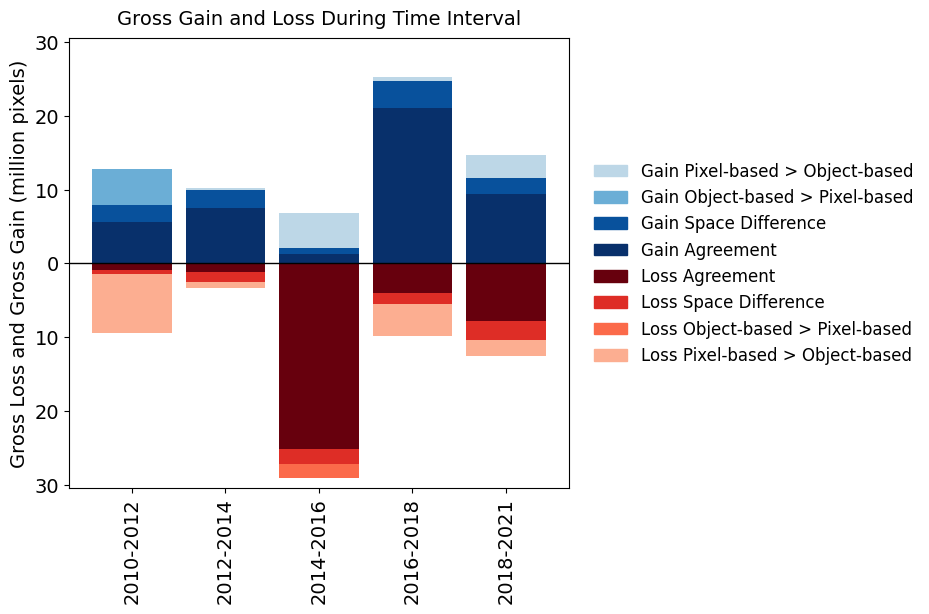

In [ ]:
# @title 4.2 Plotting Function
def plot_gross_change_chart(
    csv_path: str,
    output_dir: str
) -> None:
    """
    Reads the change assessment metrics CSV and generates a single diverging
    stacked bar chart for Gains (positive) and Losses (negative) per time interval.

    This function filters out aggregated metrics ('Total_Sum' and 'Temporal_Extent')
    and plots the gross change components using a custom blue color palette for
    Gains and a red color palette for Losses. The final chart is saved as a
    high-resolution PNG file.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the computed change assessment metrics.
    output_dir : str
        Directory where the 'charts' subfolder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Prepare Data
    df = pd.read_csv(csv_path)

    # Filter out Total_Sum and Temporal_Extent
    df_filtered = df[
        ~df['Time_Interval'].isin(['Total_Sum', 'Temporal_Extent'])
    ].copy()

    # Drop columns not needed for this chart
    if 'Time Difference' in df_filtered.columns:
        df_filtered = df_filtered.drop(columns=['Time Difference'])
    if 'Alternation' in df_filtered.columns:
        df_filtered = df_filtered.drop(columns=['Alternation'])

    # Isolate metrics and invert Losses for the diverging chart
    metrics_order = [
        'Hits',
        'Space Difference',
        'False Alarms',
        'Misses'
    ]

    loss_mask = df_filtered['Change_Type'] == 'Loss'
    df_filtered.loc[loss_mask, metrics_order] *= -1

    # Separate into Gain and Loss for plotting on the same axis
    df_gain = df_filtered[
        df_filtered['Change_Type'] == 'Gain'
    ].set_index('Time_Interval')

    df_loss = df_filtered[
        df_filtered['Change_Type'] == 'Loss'
    ].set_index('Time_Interval')

    # Dynamic Scaling Logic
    max_val_gain = df_gain[metrics_order].sum(axis=1).max()
    max_val_loss = df_loss[metrics_order].abs().sum(axis=1).max()
    max_val = max(max_val_gain, max_val_loss)

    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        y_label = "Gross Loss and Gross Gain (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        y_label = "Gross Loss and Gross Gain (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        y_label = "Gross Loss and Gross Gain (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        y_label = "Gross Loss and Gross Gain (thousand pixels)"
    elif max_val >= 100:
        scale_factor = 100
        y_label = "Gross Loss and Gross Gain (hundred pixels)"
    else:
        scale_factor = 1
        y_label = "Gross Loss and Gross Gain (pixels)"

    # Scale the data
    df_gain[metrics_order] = df_gain[metrics_order] / scale_factor
    df_loss[metrics_order] = df_loss[metrics_order] / scale_factor
    max_val_scaled = max_val / scale_factor

    # 2. Styling and Colors
    # 4 shades of Blue for Gains (Dark to Light)
    colors_gain = [
        '#08306b',  # Gain Agreement (Hits)
        '#08519c',  # Gain Space Difference
        '#6baed6',  # Gain False Alarms
        '#bdd7e7'   # Gain Misses
    ]

    # 4 shades of Red for Losses (Dark to Light)
    colors_loss = [
        '#67000d',  # Loss Agreement (Hits)
        '#de2d26',  # Loss Space Difference
        '#fb6a4a',  # Loss Time Series Y > Time Series X (False Alarms)
        '#fcae91'   # Loss Time Series X > Time Series Y (Misses)
    ]

    # 3. Generate Chart (Single Axis)
    # FIXED FIGURE SIZE AND MARGINS
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.subplots_adjust(
        left=0.1,
        right=0.60,
        top=0.90,
        bottom=0.15
    )

    # Plot Gains (Positive)
    df_gain[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_gain,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False
    )

    # Plot Losses (Negative)
    df_loss[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_loss,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False
    )

    # Force symmetric Y-axis limits so Y=0 is exactly in the center
    y_limit = max_val_scaled * 1.05
    ax.set_ylim(-y_limit, y_limit)

    # Add a solid black line at Y=0 to clearly separate gains and losses
    ax.axhline(0, color='black', linewidth=1)

    # 4. Custom Legend
    legend_elements = [
        mpatches.Patch(
            color=colors_gain[3],
            label='Gain Pixel-based > Object-based'
        ),
        mpatches.Patch(
            color=colors_gain[2],
            label='Gain Object-based > Pixel-based'
        ),
        mpatches.Patch(
            color=colors_gain[1],
            label='Gain Space Difference'
        ),
        mpatches.Patch(
            color=colors_gain[0],
            label='Gain Agreement'
        ),
        mpatches.Patch(
            color=colors_loss[0],
            label='Loss Agreement'
        ),
        mpatches.Patch(
            color=colors_loss[1],
            label='Loss Space Difference'
        ),
        mpatches.Patch(
            color=colors_loss[2],
            label='Loss Object-based > Pixel-based'
        ),
        mpatches.Patch(
            color=colors_loss[3],
            label='Loss Pixel-based > Object-based'
        ),
    ]

    ax.legend(
        handles=legend_elements,
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        frameon=False,
        fontsize=12
    )

    # 5. Styling and Formatting Clean
    ax.set_title(
        'Gross Gain and Loss During Time Interval',
        fontsize=14,
        pad=10
    )
    ax.set_ylabel(
        y_label,
        fontsize=14
    )

    # Force the X-axis label to be blank (overrides pandas default)
    ax.set_xlabel('')

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=14
    )
    plt.xticks(rotation=90)

    # Disable grid lines for a clean background
    ax.grid(False)

    # Format Y-axis to show absolute values (remove minus signs)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f"{abs(x):g}")
    )

    # Save the figure
    charts_dir = os.path.join(
        output_dir,
        "charts"
    )
    os.makedirs(
        charts_dir,
        exist_ok=True
    )

    output_file = os.path.join(
        charts_dir,
        "gross_change_intervals_chart.png"
    )

    # Remove bbox_inches='tight' to preserve exact figure size
    plt.savefig(
        output_file,
        dpi=300,
        format='png'
    )
    print(f"Chart successfully saved to: {output_file}\n")

    plt.show()

# Define the CSV path explicitly so the cell runs independently
tables_dir = os.path.join(
    output_path,
    "tables"
)
change_csv_path = os.path.join(
    tables_dir,
    "change_assessment_metrics.csv"
)

# Execute the plotting function
plot_gross_change_chart(change_csv_path, output_path)


Chart successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/charts/gross_change_sum_extent_chart.png



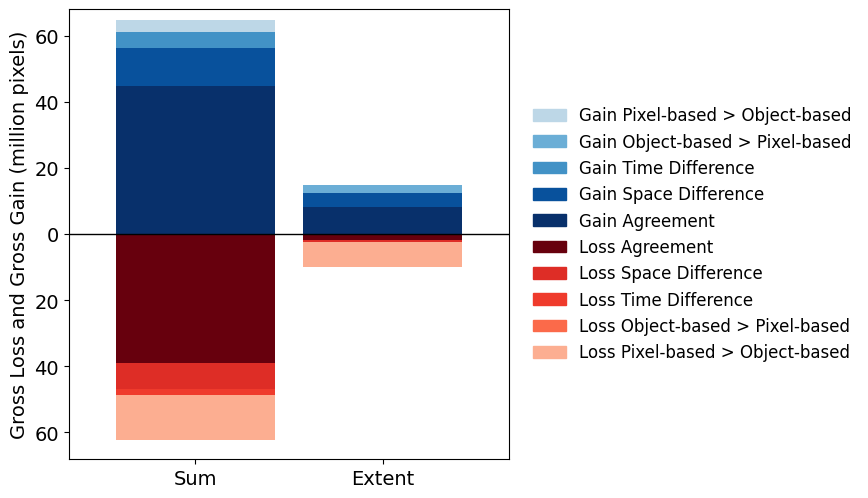

In [ ]:
# @title 4.3 Plot Sum and Extent Chart Function
def plot_sum_and_extent_chart(
    csv_path: str,
    output_dir: str
) -> None:
    """
    Reads the change assessment metrics CSV and generates a single
    diverging stacked bar chart for 'Total_Sum' and 'Temporal_Extent'.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the computed change assessment metrics.
    output_dir : str
        Directory where the 'charts' subfolder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Prepare Data
    df = pd.read_csv(csv_path)

    # Filter to keep ONLY 'Total_Sum' and 'Temporal_Extent'
    target_intervals = ['Total_Sum', 'Temporal_Extent']
    df_filtered = df[
        df['Time_Interval'].isin(target_intervals)
    ].copy()

    # Isolate the 5 specific metrics for stacking
    metrics_order = [
        'Hits',
        'Space Difference',
        'Time Difference',
        'False Alarms',
        'Misses'
    ]

    # Invert Losses to negative values for the diverging chart
    loss_mask = df_filtered['Change_Type'] == 'Loss'
    df_filtered.loc[loss_mask, metrics_order] *= -1

    # Separate into Gain and Loss for plotting on the same axis
    df_gain = df_filtered[
        df_filtered['Change_Type'] == 'Gain'
    ].set_index('Time_Interval')

    df_loss = df_filtered[
        df_filtered['Change_Type'] == 'Loss'
    ].set_index('Time_Interval')

    # Reindex to ensure proper order on the X-axis
    df_gain = df_gain.reindex(target_intervals)
    df_loss = df_loss.reindex(target_intervals)

    # Rename indices to change the x-axis labels
    rename_mapping = {'Total_Sum': 'Sum', 'Temporal_Extent': 'Extent'}
    df_gain = df_gain.rename(index=rename_mapping)
    df_loss = df_loss.rename(index=rename_mapping)

    # Dynamic Scaling Logic
    max_val_gain = df_gain[metrics_order].sum(axis=1).max()
    max_val_loss = df_loss[metrics_order].abs().sum(axis=1).max()
    max_val = max(max_val_gain, max_val_loss)

    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        y_label = "Gross Loss and Gross Gain (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        y_label = "Gross Loss and Gross Gain (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        y_label = "Gross Loss and Gross Gain (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        y_label = "Gross Loss and Gross Gain (thousand pixels)"
    elif max_val >= 100:
        scale_factor = 100
        y_label = "Gross Loss and Gross Gain (hundred pixels)"
    else:
        scale_factor = 1
        y_label = "Gross Loss and Gross Gain (pixels)"

    # Scale the data
    df_gain[metrics_order] = df_gain[metrics_order] / scale_factor
    df_loss[metrics_order] = df_loss[metrics_order] / scale_factor

    max_val_scaled = max_val / scale_factor

    # 2. Color Definition (Consistent with interval charts)
    colors_gain = [
        '#08306b',  # Gain Agreement (Hits) - EXACT MATCH
        '#08519c',  # Gain Space Difference - EXACT MATCH
        '#4292c6',  # Gain Time Difference - NEW
        '#6baed6',  # Gain False Alarms - EXACT MATCH
        '#bdd7e7'   # Gain Misses - EXACT MATCH
    ]

    colors_loss = [
        '#67000d',  # Loss Agreement (Hits) - EXACT MATCH
        '#de2d26',  # Loss Space Difference - EXACT MATCH
        '#ef3b2c',  # Loss Time Difference - NEW
        '#fb6a4a',  # Loss Object-based > Pixel-based (False Alarms) - EXACT MATCH
        '#fcae91'   # Loss Pixel-based > Object-based (Misses) - EXACT MATCH
    ]

    # 3. Plotting the Single Chart
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.15
    )

    # Plot Gains (Positive)
    df_gain[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_gain,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False
    )

    # Plot Losses (Negative)
    df_loss[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_loss,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False
    )

    # Force symmetric Y-axis limits so Y=0 is exactly in the center
    y_limit = max_val_scaled * 1.05
    ax.set_ylim(-y_limit, y_limit)

    # Keep the solid black line at Y=0
    ax.axhline(
        0,
        color='black',
        linewidth=1
    )

    # 4. Custom Legend
    legend_elements = [
        mpatches.Patch(
            color=colors_gain[4],
            label='Gain Pixel-based > Object-based'
        ),
        mpatches.Patch(
            color=colors_gain[3],
            label='Gain Object-based > Pixel-based'
        ),
        mpatches.Patch(
            color=colors_gain[2],
            label='Gain Time Difference'
        ),
        mpatches.Patch(
            color=colors_gain[1],
            label='Gain Space Difference'
        ),
        mpatches.Patch(
            color=colors_gain[0],
            label='Gain Agreement'
        ),
        mpatches.Patch(
            color=colors_loss[0],
            label='Loss Agreement'
        ),
        mpatches.Patch(
            color=colors_loss[1],
            label='Loss Space Difference'
        ),
        mpatches.Patch(
            color=colors_loss[2],
            label='Loss Time Difference'
        ),
        mpatches.Patch(
            color=colors_loss[3],
            label='Loss Object-based > Pixel-based'
        ),
        mpatches.Patch(
            color=colors_loss[4],
            label='Loss Pixel-based > Object-based'
        ),
    ]

    ax.legend(
        handles=legend_elements,
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        frameon=False,
        fontsize=12
    )

    # 5. Clean Style and Formatting
    ax.set_ylabel(
        y_label,
        fontsize=14
    )
    ax.set_xlabel('')

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=14
    )
    plt.xticks(
        rotation=0
    )

    # No horizontal or vertical grid lines
    ax.grid(
        False
    )

    # Y-axis formatted with absolute values (no minus sign)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(
            lambda x, pos: f"{abs(x):g}"
        )
    )

    # Save the figure
    charts_dir = os.path.join(
        output_dir,
        "charts"
    )
    os.makedirs(
        charts_dir,
        exist_ok=True
    )

    output_file = os.path.join(
        charts_dir,
        "gross_change_sum_extent_chart.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        format='png'
    )
    print(f"Chart successfully saved to: {output_file}\n")

    plt.show()

# Define the CSV path explicitly
tables_dir = os.path.join(
    output_path,
    "tables"
)
change_csv_path = os.path.join(
    tables_dir,
    "change_assessment_metrics.csv"
)

# Execute the plotting function
plot_sum_and_extent_chart(
    csv_path=change_csv_path,
    output_dir=output_path
)


In [ ]:
# @title 4.4 Net Change Assessment Functions
# 1. Optimized Helper Functions
def compute_net_sums_block(
    arr_x0: np.ndarray,
    arr_x1: np.ndarray,
    arr_y0: np.ndarray,
    arr_y1: np.ndarray,
    no_data_val: int,
    presence_val: int,
) -> Tuple[int, int, int, int]:
    """
    Computes total sums of gains and losses for a single spatial block.

    This optimized version uses boolean masks and count_nonzero for
    maximum performance on large raster datasets.

    Parameters
    ----------
    arr_x0 : np.ndarray
        Array for Time Series X at time t-1.
    arr_x1 : np.ndarray
        Array for Time Series X at time t.
    arr_y0 : np.ndarray
        Array for Time Series Y at time t-1.
    arr_y1 : np.ndarray
        Array for Time Series Y at time t.
    no_data_val : int
        Pixel value indicating no data.
    presence_val : int
        Pixel value indicating presence.

    Returns
    -------
    Tuple[int, int, int, int]
        A tuple containing (Gain X count, Gain Y count, Loss X count, Loss Y count).
        Losses are returned as negative integers to match original logic.
    """
    # Create masks for valid pixels and presence
    valid_mask = (
        (arr_x0 != no_data_val) &
        (arr_x1 != no_data_val) &
        (arr_y0 != no_data_val) &
        (arr_y1 != no_data_val)
    )

    m_x0 = (arr_x0 == presence_val) & valid_mask
    m_x1 = (arr_x1 == presence_val) & valid_mask
    m_y0 = (arr_y0 == presence_val) & valid_mask
    m_y1 = (arr_y1 == presence_val) & valid_mask

    # Net Gain: 0 -> 1 transitions
    # Net Loss: 1 -> 0 transitions
    gx = np.count_nonzero(m_x1 & ~m_x0)
    gy = np.count_nonzero(m_y1 & ~m_y0)
    lx = np.count_nonzero(~m_x1 & m_x0)
    ly = np.count_nonzero(~m_y1 & m_y0)

    # Return counts, losses as negative to maintain original logic
    return (
        int(gx),
        int(gy),
        int(-lx),
        int(-ly),
    )


# 2. Net Change Assessment Execution
def calculate_net_change_assessment(
    ts_x_paths: List[str],
    ts_y_paths: List[str],
    no_data_val: int = 255,
    presence_val: int = 1,
    output_csv: str = "net_change_assessment_metrics.csv",
) -> pd.DataFrame:
    """
    Executes Net Change Assessment (Quantity Change) over time series.

    Processes intervals between maps to calculate net gain and loss,
    aggregating results for intervals, total sum, and temporal extent.

    Parameters
    ----------
    ts_x_paths : List[str]
        Paths to Time Series X.
    ts_y_paths : List[str]
        Paths to Time Series Y.
    no_data_val : int, optional
        Value for invalid pixels, by default 255.
    presence_val : int, optional
        Value for presence, by default 1.
    output_csv : str, optional
        Path for output CSV, by default "net_change_assessment_metrics.csv".

    Returns
    -------
    pd.DataFrame
        Net Change metrics configured for a diverging stacked chart.
    """
    results = []

    # Aggregators for total series metrics
    total_qg_x, total_qg_y = 0, 0
    total_ql_x, total_ql_y = 0, 0
    qgh_total, qlh_total = 0, 0

    num_intervals = len(ts_x_paths) - 1

    # 2.1 Process Intervals (t-1 to t)
    pbar_intervals = tqdm(
        range(num_intervals),
        desc="1/2 Net Assessment Intervals",
    )

    for t in pbar_intervals:
        path_x0, path_x1 = ts_x_paths[t], ts_x_paths[t + 1]
        path_y0, path_y1 = ts_y_paths[t], ts_y_paths[t + 1]

        # Year label identification
        m0 = re.search(r"\d{4}", path_x0)
        m1 = re.search(r"\d{4}", path_x1)
        interval = (
            f"{m0.group(0)}-{m1.group(0)}"
            if (m0 and m1)
            else f"T{t + 1}"
        )

        gx, gy, lx, ly = 0, 0, 0, 0

        with rasterio.open(path_x0) as sx0, \
             rasterio.open(path_x1) as sx1, \
             rasterio.open(path_y0) as sy0, \
             rasterio.open(path_y1) as sy1:

            windows = list(sx0.block_windows())
            pbar_blocks = tqdm(
                windows,
                desc=f"   -> {interval}",
                leave=False,
            )

            for _, window in pbar_blocks:
                gxb, gyb, lxb, lyb = compute_net_sums_block(
                    sx0.read(1, window=window),
                    sx1.read(1, window=window),
                    sy0.read(1, window=window),
                    sy1.read(1, window=window),
                    no_data_val,
                    presence_val,
                )
                gx += gxb
                gy += gyb
                lx += lxb
                ly += lyb

        # Calculate Quantity Gain and Loss for the interval
        qg_x = max(0, gx + lx)
        qg_y = max(0, gy + ly)
        ql_x = min(0, gx + lx)
        ql_y = min(0, gy + ly)

        # Update series totals
        total_qg_x += qg_x
        total_qg_y += qg_y
        total_ql_x += ql_x
        total_ql_y += ql_y

        # Intersection and differences for Gain
        qgh = min(qg_x, qg_y)
        qgf = max(0, qg_y - qg_x)
        qgm = max(0, qg_x - qg_y)

        # Intersection and differences for Loss
        qlh = max(ql_x, ql_y)
        qlf = min(0, ql_y - ql_x)
        qlm = min(0, ql_x - ql_y)

        qgh_total += qgh
        qlh_total += qlh

        results.append({
            "Time_Interval": interval,
            "Change_Type": "Gain",
            "Hits": qgh,
            "False Alarms": qgf,
            "Misses": qgm,
            "Space Difference": 0,
            "Time Difference": 0,
            "Alternation": 0,
        })
        results.append({
            "Time_Interval": interval,
            "Change_Type": "Loss",
            "Hits": abs(qlh),
            "False Alarms": abs(qlf),
            "Misses": abs(qlm),
            "Space Difference": 0,
            "Time Difference": 0,
            "Alternation": 0,
        })

        # Free memory buffers
        gc.collect()

    # 2.2 Calculate Total_Sum logic (with Quantity-based Time Difference)
    qgv = min(total_qg_x, total_qg_y) - qgh_total
    qlv = max(total_ql_x, total_ql_y) - qlh_total

    results.append({
        "Time_Interval": "Total_Sum",
        "Change_Type": "Gain",
        "Hits": qgh_total,
        "False Alarms": max(0, total_qg_y - total_qg_x),
        "Misses": max(0, total_qg_x - total_qg_y),
        "Space Difference": 0,
        "Time Difference": qgv,
        "Alternation": 0,
    })
    results.append({
        "Time_Interval": "Total_Sum",
        "Change_Type": "Loss",
        "Hits": abs(qlh_total),
        "False Alarms": abs(max(total_ql_y, total_ql_x) - min(total_ql_y, total_ql_x)),
        "False Alarms": max(0, abs(total_ql_y) - abs(total_ql_x)),
        "Misses": max(0, abs(total_ql_x) - abs(total_ql_y)),
        "Space Difference": 0,
        "Time Difference": abs(qlv),
        "Alternation": 0,
    })

    # 3. Temporal Extent (First map vs Last map)
    ext_gx, ext_gy, ext_lx, ext_ly = 0, 0, 0, 0
    with rasterio.open(ts_x_paths[0]) as sx0, \
         rasterio.open(ts_x_paths[-1]) as sx1, \
         rasterio.open(ts_y_paths[0]) as sy0, \
         rasterio.open(ts_y_paths[-1]) as sy1:

        ext_windows = list(sx0.block_windows())
        pbar_ext = tqdm(
            ext_windows,
            desc="2/2 Temporal Extent",
        )

        for _, window in pbar_ext:
            gxb, gyb, lxb, lyb = compute_net_sums_block(
                sx0.read(1, window=window),
                sx1.read(1, window=window),
                sy0.read(1, window=window),
                sy1.read(1, window=window),
                no_data_val,
                presence_val,
            )
            ext_gx += gxb
            ext_gy += gyb
            ext_lx += lxb
            ext_ly += lyb

    # Net quantity change for the entire temporal extent
    ext_qg_x = max(0, ext_gx + ext_lx)
    ext_qg_y = max(0, ext_gy + ext_ly)
    ext_ql_x = min(0, ext_gx + ext_lx)
    ext_ql_y = min(0, ext_gy + ext_ly)

    results.append({
        "Time_Interval": "Temporal_Extent",
        "Change_Type": "Gain",
        "Hits": min(ext_qg_x, ext_qg_y),
        "False Alarms": max(0, ext_qg_y - ext_qg_x),
        "Misses": max(0, ext_qg_x - ext_qg_y),
        "Space Difference": 0,
        "Time Difference": 0,
        "Alternation": 0,
    })
    results.append({
        "Time_Interval": "Temporal_Extent",
        "Change_Type": "Loss",
        "Hits": abs(max(ext_ql_x, ext_ql_y)),
        "False Alarms": abs(min(0, ext_ql_y - ext_ql_x)),
        "Misses": abs(min(0, ext_ql_x - ext_ql_y)),
        "Space Difference": 0,
        "Time Difference": 0,
        "Alternation": 0,
    })

    # 3. Post-processing: Alternation and Export
    df = pd.DataFrame(results)

    # Calculate Alternation for Total_Sum row
    metrics = ["Hits", "False Alarms", "Misses", "Space Difference"]
    for c_type in ["Gain", "Loss"]:
        mask_tot = (df["Time_Interval"] == "Total_Sum") & (df["Change_Type"] == c_type)
        mask_ext = (df["Time_Interval"] == "Temporal_Extent") & (df["Change_Type"] == c_type)

        v_tot = df.loc[mask_tot, metrics].sum(axis=1).values[0]
        v_ext = df.loc[mask_ext, metrics].sum(axis=1).values[0]
        df.loc[mask_tot, "Alternation"] = v_tot - v_ext

    df.to_csv(output_csv, index=False)

    print(f"Net Change Assessment completed.\nCSV saved to: {output_csv}\n")

    return df


# 4. Execution Logic
# Prepare output structure
tables_dir = os.path.join(output_path, "tables")
os.makedirs(tables_dir, exist_ok=True)
net_change_csv_path = os.path.join(tables_dir, "net_change_assessment_metrics.csv")

# Start processing
df_net_change = calculate_net_change_assessment(
    ts_x_paths=time_series_x,
    ts_y_paths=time_series_y,
    no_data_val=no_data_value,
    presence_val=presence_value,
    output_csv=net_change_csv_path,
)

# Display final table
display(df_net_change)

1/2 Net Assessment Intervals:   0%|          | 0/5 [00:00<?, ?it/s]

   -> 2010-2012:   0%|          | 0/22568 [00:00<?, ?it/s]

   -> 2012-2014:   0%|          | 0/22568 [00:00<?, ?it/s]

   -> 2014-2016:   0%|          | 0/22568 [00:00<?, ?it/s]

   -> 2016-2018:   0%|          | 0/22568 [00:00<?, ?it/s]

   -> 2018-2021:   0%|          | 0/22568 [00:00<?, ?it/s]

2/2 Temporal Extent:   0%|          | 0/22568 [00:00<?, ?it/s]

Net Change Assessment completed.
CSV saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/tables/net_change_assessment_metrics.csv



,Time_Interval,Change_Type,Hits,False Alarms,Misses,Space Difference,Time Difference,Alternation
0,2010-2012,Gain,0,11429104,0,0,0,0
1,2010-2012,Loss,0,0,1554781,0,0,0
2,2012-2014,Gain,6862390,638450,0,0,0,0
3,2012-2014,Loss,0,0,0,0,0,0
4,2014-2016,Gain,0,0,0,0,0,0
5,2014-2016,Loss,20361974,6545457,0,0,0,0
6,2016-2018,Gain,15515317,3724537,0,0,0,0
7,2016-2018,Loss,0,0,0,0,0,0
8,2018-2021,Gain,1176726,0,928673,0,0,0
9,2018-2021,Loss,0,0,0,0,0,0


Chart successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/charts/net_change_intervals_chart.png



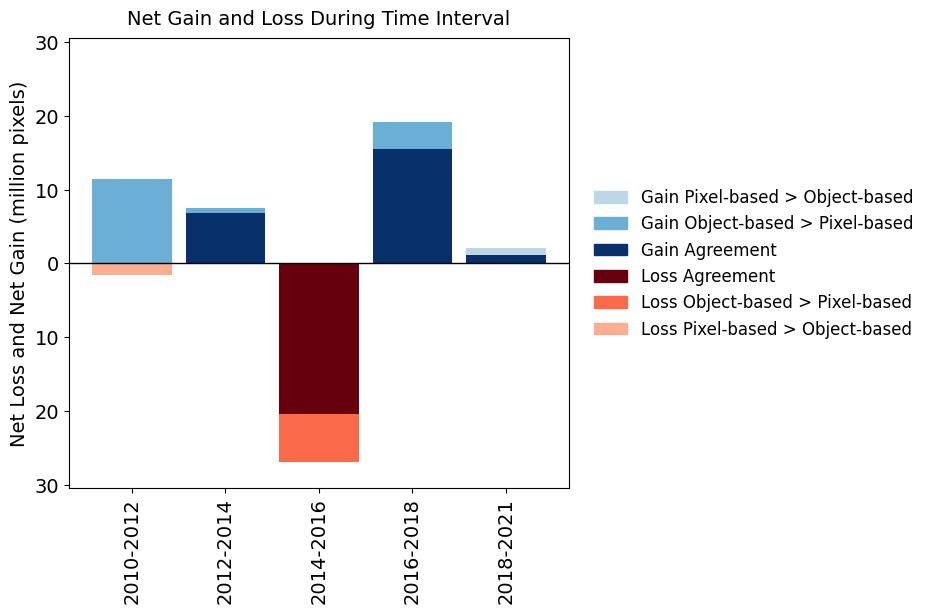

In [ ]:
# @title 4.5 Plotting Function for Net Change Assessment
def plot_net_change_chart(csv_path: str, gross_csv_path: str, output_dir: str) -> None:
    """
    Reads the change assessment metrics CSV and generates a single diverging
    stacked bar chart for Gains (positive) and Losses (negative) per time interval.

    This function filters out aggregated metrics ('Total_Sum' and 'Temporal_Extent')
    and plots the net change components using a custom blue color palette for
    Gains and a red color palette for Losses. The Y-axis is scaled to match the
    Gross Change chart for direct visual comparison. The final chart is saved as a
    high-resolution PNG file.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the computed NET change assessment metrics.
    gross_csv_path : str
        Path to the CSV file containing the computed GROSS change assessment metrics.
    output_dir : str
        Directory where the 'charts' subfolder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Prepare Data
    df = pd.read_csv(csv_path)
    df_gross = pd.read_csv(gross_csv_path)

    # Filter out Total_Sum and Temporal_Extent
    df_filtered = df[
        ~df['Time_Interval'].isin(['Total_Sum', 'Temporal_Extent'])
    ].copy()

    df_gross_filtered = df_gross[
        ~df_gross['Time_Interval'].isin(['Total_Sum', 'Temporal_Extent'])
    ].copy()

    # Drop columns not needed for this chart
    if 'Time Difference' in df_filtered.columns:
        df_filtered = df_filtered.drop(columns=['Time Difference'])
    if 'Alternation' in df_filtered.columns:
        df_filtered = df_filtered.drop(columns=['Alternation'])

    # Isolate metrics and invert Losses for the diverging chart
    metrics_order = [
        'Hits',
        'Space Difference',
        'False Alarms',
        'Misses'
    ]

    loss_mask = df_filtered['Change_Type'] == 'Loss'
    df_filtered.loc[loss_mask, metrics_order] *= -1

    # Separate into Gain and Loss for plotting on the same axis
    df_gain = df_filtered[
        df_filtered['Change_Type'] == 'Gain'
    ].set_index('Time_Interval')

    df_loss = df_filtered[
        df_filtered['Change_Type'] == 'Loss'
    ].set_index('Time_Interval')

    # Dynamic Scaling Logic based on GROSS data to sync Y-axis limits
    max_val_gain_gross = df_gross_filtered[df_gross_filtered['Change_Type'] == 'Gain'][metrics_order].sum(axis=1).max()
    max_val_loss_gross = df_gross_filtered[df_gross_filtered['Change_Type'] == 'Loss'][metrics_order].sum(axis=1).max()
    max_val_gross = max(max_val_gain_gross, max_val_loss_gross)

    if max_val_gross >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        y_label = "Net Loss and Net Gain (trillion pixels)"
    elif max_val_gross >= 1_000_000_000:
        scale_factor = 1_000_000_000
        y_label = "Net Loss and Net Gain (billion pixels)"
    elif max_val_gross >= 1_000_000:
        scale_factor = 1_000_000
        y_label = "Net Loss and Net Gain (million pixels)"
    elif max_val_gross >= 1_000:
        scale_factor = 1_000
        y_label = "Net Loss and Net Gain (thousand pixels)"
    elif max_val_gross >= 100:
        scale_factor = 100
        y_label = "Net Loss and Net Gain (hundred pixels)"
    else:
        scale_factor = 1
        y_label = "Net Loss and Net Gain (pixels)"

    # Scale the NET data
    df_gain[metrics_order] = df_gain[metrics_order] / scale_factor
    df_loss[metrics_order] = df_loss[metrics_order] / scale_factor

    # Scaled max value for invisible limits
    max_val_scaled_gross = max_val_gross / scale_factor

    # 2. Styling and Colors
    # 4 shades of Blue for Gains (Dark to Light)
    colors_gain = [
        '#08306b',  # Gain Agreement (Hits)
        '#08519c',  # Gain Space Difference
        '#6baed6',  # Gain False Alarms
        '#bdd7e7'   # Gain Misses
    ]

    # 4 shades of Red for Losses (Dark to Light)
    colors_loss = [
        '#67000d',  # Loss Agreement (Hits)
        '#de2d26',  # Loss Space Difference
        '#fb6a4a',  # Loss Time Series Y > Time Series X (False Alarms)
        '#fcae91'   # Loss Time Series X > Time Series Y (Misses)
    ]

    # 3. Generate Chart (Single Axis)
    # FIXED FIGURE SIZE AND MARGINS
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.subplots_adjust(
        left=0.1,
        right=0.60,
        top=0.90,
        bottom=0.15
    )

    # Plot Gains (Positive)
    df_gain[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_gain,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False
    )

    # Plot Losses (Negative)
    df_loss[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_loss,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False
    )

    # Force symmetric Y-axis limits based on GROSS data so Y=0 is exactly in the center
    y_limit = max_val_scaled_gross * 1.05
    ax.set_ylim(-y_limit, y_limit)

    # Add a solid black line at Y=0 to clearly separate gains and losses
    ax.axhline(0, color='black', linewidth=1)

    # 4. Custom Legend
    # Calculate sums to filter out empty categories
    gain_sums = df_gain[metrics_order].sum()
    loss_sums = df_loss[metrics_order].abs().sum()

    legend_elements = []
    if gain_sums['Misses'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_gain[3], label='Gain Pixel-based > Object-based'))
    if gain_sums['False Alarms'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_gain[2], label='Gain Object-based > Pixel-based'))
    if gain_sums['Space Difference'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_gain[1], label='Gain Space Difference'))
    if gain_sums['Hits'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_gain[0], label='Gain Agreement'))

    if loss_sums['Hits'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_loss[0], label='Loss Agreement'))
    if loss_sums['Space Difference'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_loss[1], label='Loss Space Difference'))
    if loss_sums['False Alarms'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_loss[2], label='Loss Object-based > Pixel-based'))
    if loss_sums['Misses'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_loss[3], label='Loss Pixel-based > Object-based'))

    ax.legend(
        handles=legend_elements,
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        frameon=False,
        fontsize=12
    )

    # 5. Styling and Formatting Clean
    ax.set_title(
        'Net Gain and Loss During Time Interval',
        fontsize=14,
        pad=10
    )
    ax.set_ylabel(
        y_label,
        fontsize=14
    )

    # Forçar o rótulo do eixo X a ficar em branco (sobrescreve o padrão do pandas)
    ax.set_xlabel('')

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=14
    )
    plt.xticks(rotation=90)

    # Disable grid lines for a clean background
    ax.grid(False)

    # Format Y-axis to show absolute values (remove minus signs)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f"{abs(x):g}")
    )

    # Remove tight_layout as it conflicts with subplots_adjust
    # plt.tight_layout()

    # Save the figure
    charts_dir = os.path.join(
        output_dir,
        "charts"
    )
    os.makedirs(
        charts_dir,
        exist_ok=True
    )

    output_file = os.path.join(
        charts_dir,
        "net_change_intervals_chart.png"
    )

    # Remove bbox_inches='tight' to preserve exact figure size
    plt.savefig(
        output_file,
        dpi=300,
        format='png'
    )
    print(f"Chart successfully saved to: {output_file}\n")

    plt.show()

# Define the CSV paths explicitly
tables_dir = os.path.join(
    output_path,
    "tables"
)
net_change_csv_path = os.path.join(
    tables_dir,
    "net_change_assessment_metrics.csv"
)
change_csv_path = os.path.join(
    tables_dir,
    "change_assessment_metrics.csv"
)

# Execute the plotting function
plot_net_change_chart(net_change_csv_path, change_csv_path, output_path)


Chart successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/charts/net_change_sum_extent_chart.png



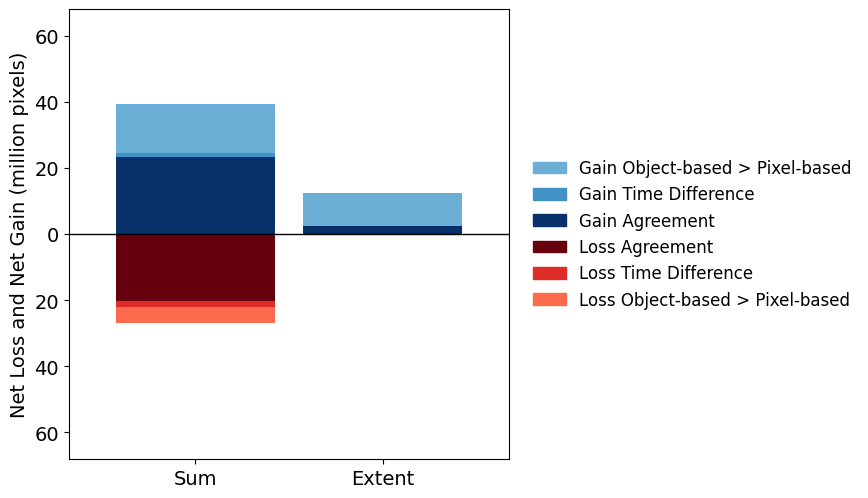

In [ ]:
# @title 4.6 Plotting Function for Net Sum and Temporal Extent
def plot_net_sum_and_extent_chart(
    csv_path: str,
    gross_csv_path: str,
    output_dir: str
) -> None:
    """
    Reads the change assessment metrics CSV and generates a single
    diverging stacked bar chart for 'Total_Sum' and 'Temporal_Extent'.

    The Y-axis is scaled to match the Gross Change chart for direct
    visual comparison.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the computed NET change assessment metrics.
    gross_csv_path : str
        Path to the CSV file containing the computed GROSS change assessment metrics.
    output_dir : str
        Directory where the 'charts' subfolder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Prepare Data
    df = pd.read_csv(csv_path)
    df_gross = pd.read_csv(gross_csv_path)

    # Filter to keep ONLY 'Total_Sum' and 'Temporal_Extent'
    target_intervals = ['Total_Sum', 'Temporal_Extent']
    df_filtered = df[
        df['Time_Interval'].isin(target_intervals)
    ].copy()

    df_gross_filtered = df_gross[
        df_gross['Time_Interval'].isin(target_intervals)
    ].copy()

    # Isolate the 5 specific metrics for stacking
    metrics_order = [
        'Hits',
        'Space Difference',
        'Time Difference',
        'False Alarms',
        'Misses'
    ]

    # Invert Losses to negative values for the diverging chart
    loss_mask = df_filtered['Change_Type'] == 'Loss'
    df_filtered.loc[loss_mask, metrics_order] *= -1

    # Separate into Gain and Loss for plotting on the same axis
    df_gain = df_filtered[
        df_filtered['Change_Type'] == 'Gain'
    ].set_index('Time_Interval')

    df_loss = df_filtered[
        df_filtered['Change_Type'] == 'Loss'
    ].set_index('Time_Interval')

    # Reindex to ensure proper order on the X-axis
    df_gain = df_gain.reindex(target_intervals)
    df_loss = df_loss.reindex(target_intervals)

    # Rename indices to change the x-axis labels
    rename_mapping = {'Total_Sum': 'Sum', 'Temporal_Extent': 'Extent'}
    df_gain = df_gain.rename(index=rename_mapping)
    df_loss = df_loss.rename(index=rename_mapping)

    # Dynamic Scaling Logic based on GROSS data to sync Y-axis limits
    max_val_gain_gross = df_gross_filtered[df_gross_filtered['Change_Type'] == 'Gain'][metrics_order].sum(axis=1).max()
    max_val_loss_gross = df_gross_filtered[df_gross_filtered['Change_Type'] == 'Loss'][metrics_order].sum(axis=1).max()
    max_val_gross = max(max_val_gain_gross, max_val_loss_gross)

    if max_val_gross >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        y_label = "Net Loss and Net Gain (trillion pixels)"
    elif max_val_gross >= 1_000_000_000:
        scale_factor = 1_000_000_000
        y_label = "Net Loss and Net Gain (billion pixels)"
    elif max_val_gross >= 1_000_000:
        scale_factor = 1_000_000
        y_label = "Net Loss and Net Gain (million pixels)"
    elif max_val_gross >= 1_000:
        scale_factor = 1_000
        y_label = "Net Loss and Net Gain (thousand pixels)"
    elif max_val_gross >= 100:
        scale_factor = 100
        y_label = "Net Loss and Net Gain (hundred pixels)"
    else:
        scale_factor = 1
        y_label = "Net Loss and Net Gain (pixels)"

    # Scale the NET data
    df_gain[metrics_order] = df_gain[metrics_order] / scale_factor
    df_loss[metrics_order] = df_loss[metrics_order] / scale_factor

    # Scaled max value for symmetric limits
    max_val_scaled_gross = max_val_gross / scale_factor

    # 2. Definição de Cores (Azul vs Vermelho)
    # 5 shades of Blue for Gains (Dark to Light)
    colors_gain = [
        '#08306b',  # Gain Hits
        '#08519c',  # Gain Space Difference
        '#4292c6',  # Gain Time Difference
        '#6baed6',  # Gain False Alarms
        '#bdd7e7'   # Gain Misses
    ]

    # 5 shades of Red for Losses (Dark to Light)
    colors_loss = [
        '#67000d',  # Loss Hits
        '#a50f15',  # Loss Space Difference
        '#de2d26',  # Loss Time Difference
        '#fb6a4a',  # Loss Time Series Y > Time Series X (False Alarms)
        '#fcae91'   # Loss Time Series X > Time Series Y (Misses)
    ]

    # 3. Plotagem do Gráfico Único
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.15
    )

    # Plot Gains (Positive)
    df_gain[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_gain,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False
    )

    # Plot Losses (Negative)
    df_loss[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_loss,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False
    )

    # Force symmetric Y-axis limits based on GROSS data so Y=0 is exactly in the center
    y_limit = max_val_scaled_gross * 1.05
    ax.set_ylim(-y_limit, y_limit)

    # Mantenha a linha preta sólida em Y=0
    ax.axhline(
        0,
        color='black',
        linewidth=1
    )

    # 4. Legenda Customizada (Matplotlib Patch)
    # Calculate sums to filter out empty categories
    gain_sums = df_gain[metrics_order].sum()
    loss_sums = df_loss[metrics_order].abs().sum()

    legend_elements = []
    if gain_sums['Misses'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_gain[4], label='Gain Pixel-based > Object-based'))
    if gain_sums['False Alarms'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_gain[3], label='Gain Object-based > Pixel-based'))
    if gain_sums['Time Difference'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_gain[2], label='Gain Time Difference'))
    if gain_sums['Space Difference'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_gain[1], label='Gain Space Difference'))
    if gain_sums['Hits'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_gain[0], label='Gain Agreement'))

    if loss_sums['Hits'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_loss[0], label='Loss Agreement'))
    if loss_sums['Space Difference'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_loss[1], label='Loss Space Difference'))
    if loss_sums['Time Difference'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_loss[2], label='Loss Time Difference'))
    if loss_sums['False Alarms'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_loss[3], label='Loss Object-based > Pixel-based'))
    if loss_sums['Misses'] > 0:
        legend_elements.append(mpatches.Patch(color=colors_loss[4], label='Loss Pixel-based > Object-based'))

    ax.legend(
        handles=legend_elements,
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        frameon=False,
        fontsize=12
    )

    # 5. Estilo e Formatação Limpa
    ax.set_ylabel(
        y_label,
        fontsize=14
    )
    ax.set_xlabel('')

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=14
    )
    plt.xticks(
        rotation=0
    )

    # Sem linhas de grade horizontais ou verticais
    ax.grid(
        False
    )

    # Eixo Y formatado com valores absolutos (sem sinal de menos)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(
            lambda x, pos: f"{abs(x):g}"
        )
    )

    # Save the figure
    charts_dir = os.path.join(
        output_dir,
        "charts"
    )
    os.makedirs(
        charts_dir,
        exist_ok=True
    )

    output_file = os.path.join(
        charts_dir,
        "net_change_sum_extent_chart.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        format='png'
    )
    print(f"Chart successfully saved to: {output_file}\n")

    plt.show()

# Define the CSV paths explicitly
tables_dir = os.path.join(
    output_path,
    "tables"
)
net_change_csv_path = os.path.join(
    tables_dir,
    "net_change_assessment_metrics.csv"
)
change_csv_path = os.path.join(
    tables_dir,
    "change_assessment_metrics.csv"
)

# Execute the plotting function
plot_net_sum_and_extent_chart(
    csv_path=net_change_csv_path,
    gross_csv_path=change_csv_path,
    output_dir=output_path
)

## **5.Spatial Maps**

### 5.1 Presence Maps

In [ ]:
# @title 5.1.1 Compute Presence Maps
def generate_presence_maps(
    ts_x_paths: List[str],
    ts_y_paths: List[str],
    output_dir: str,
    no_data_val: int = no_data_value,
    presence_val: int = presence_value
) -> None:
    """
    Generates the three Presence Maps (A, B, and C) based on the
    methodology by Pontius Jr. et al. (Equations 49, 50, 51).

    Parameters
    ----------
    ts_x_paths : List[str]
        List of file paths for Time Series X.
    ts_y_paths : List[str]
        List of file paths for Time Series Y.
    output_dir : str
        Directory where the output maps will be saved.
    no_data_val : int, optional
        Pixel value indicating no data, by default no_data_value.
    presence_val : int, optional
        Pixel value indicating presence, by default presence_value.

    Returns
    -------
    None
    """
    # Ensure output directory exists (create 'rasters' subfolder)
    maps_dir = os.path.join(
        output_dir,
        "rasters"
    )
    os.makedirs(
        maps_dir,
        exist_ok=True
    )

    # Define output file paths
    path_a = os.path.join(
        maps_dir,
        "presence_map_A_hits.tif"
    )
    path_b = os.path.join(
        maps_dir,
        "presence_map_B_difference.tif"
    )
    path_c = os.path.join(
        maps_dir,
        "presence_map_C_temporal_allocation.tif"
    )

    # Open the first file to retrieve metadata and block windows
    with rasterio.open(
        ts_x_paths[0]
    ) as src_ref:
        meta = src_ref.meta.copy()
        windows = [
            window for _, window in src_ref.block_windows()
        ]

    # Update metadata for minimal typing and compression
    meta.update({
        'dtype': rasterio.int16,
        'nodata': no_data_val,
        'compress': 'deflate'
    })

    print(
        "Generating Presence Maps..."
    )
    print(
        f"Map A: {path_a}"
    )
    print(
        f"Map B: {path_b}"
    )
    print(
        f"Map C: {path_c}"
    )

    # Use ExitStack to manage multiple open files efficiently
    with ExitStack() as stack:
        # Open all source readers once
        srcs_x = [
            stack.enter_context(
                rasterio.open(
                    p
                )
            ) for p in ts_x_paths
        ]
        srcs_y = [
            stack.enter_context(
                rasterio.open(
                    p
                )
            ) for p in ts_y_paths
        ]

        # Open output writers
        dst_a = stack.enter_context(
            rasterio.open(
                path_a,
                'w',
                **meta
            )
        )
        dst_b = stack.enter_context(
            rasterio.open(
                path_b,
                'w',
                **meta
            )
        )
        dst_c = stack.enter_context(
            rasterio.open(
                path_c,
                'w',
                **meta
            )
        )

        # Iterate over spatial blocks (windows)
        for window in tqdm(
            windows,
            desc="Processing Spatial Blocks"
        ):
            height, width = window.height, window.width

            sum_hits = np.zeros(
                (height, width),
                dtype=np.int16
            )
            sum_diff = np.zeros(
                (height, width),
                dtype=np.int16
            )
            sum_abs_diff = np.zeros(
                (height, width),
                dtype=np.int16
            )

            # Initialize a valid mask (True means valid pixel)
            valid_mask = np.ones(
                (height, width),
                dtype=bool
            )

            # Iterate over the pre-opened time points
            for sx, sy in zip(
                srcs_x,
                srcs_y
            ):
                arr_x = sx.read(
                    1,
                    window=window
                )
                arr_y = sy.read(
                    1,
                    window=window
                )

                # Update valid mask (must be valid in all time steps)
                valid_mask &= (
                    arr_x != no_data_val
                )
                valid_mask &= (
                    arr_y != no_data_val
                )

                # Normalize arrays: 1 for presence, 0 for absence
                p_x = np.where(
                    arr_x == presence_val,
                    1,
                    0
                ).astype(
                    np.int16
                )
                p_y = np.where(
                    arr_y == presence_val,
                    1,
                    0
                ).astype(
                    np.int16
                )

                # Eq 49 (Hits): MINIMUM(P_x, P_y)
                sum_hits += np.minimum(
                    p_x,
                    p_y
                )

                # Difference (P_y - P_x)
                diff = p_y - p_x

                # Accumulate diff for Eq 50
                sum_diff += diff

                # Accumulate absolute diff for Eq 51
                sum_abs_diff += np.abs(
                    diff
                )

            # Eq 51 (Temporal Allocation Diff): Sum(|P_y-P_x|) - |Sum(P_y-P_x)|
            c_arr = sum_abs_diff - np.abs(
                sum_diff
            )

            # Mask out no_data pixels
            out_a = np.where(
                valid_mask,
                sum_hits,
                no_data_val
            )
            out_b = np.where(
                valid_mask,
                sum_diff,
                no_data_val
            )
            out_c = np.where(
                valid_mask,
                c_arr,
                no_data_val
            )

            # Write blocks to disk
            dst_a.write(
                out_a.astype(
                    np.int16
                ),
                1,
                window=window
            )
            dst_b.write(
                out_b.astype(
                    np.int16
                ),
                1,
                window=window
            )
            dst_c.write(
                out_c.astype(
                    np.int16
                ),
                1,
                window=window
            )

    print(
        "\nPresence Maps generated successfully!"
    )


# Execute the function
generate_presence_maps(
    ts_x_paths=time_series_x,
    ts_y_paths=time_series_y,
    output_dir=output_path,
    no_data_val=no_data_value,
    presence_val=presence_value
)


Generating Presence Maps...
Map A: /content/drive/MyDrive/Assessments/compare-time-series/extent2/rasters/presence_map_A_hits.tif
Map B: /content/drive/MyDrive/Assessments/compare-time-series/extent2/rasters/presence_map_B_difference.tif
Map C: /content/drive/MyDrive/Assessments/compare-time-series/extent2/rasters/presence_map_C_temporal_allocation.tif


Processing Spatial Blocks:   0%|          | 0/22568 [00:00<?, ?it/s]


Presence Maps generated successfully!


5.1.2 Plot Presence Map

In [9]:
# @title Helper function
def compute_display_pixel_size_m(
    raster_path: str,
    downsample_divisor: int,
) -> float:
    """
    Compute horizontal resolution in meters per displayed pixel.

    Parameters
    ----------
    raster_path : str
        Path to a raster file used to derive spatial extent and CRS.
    downsample_divisor : int
        Integer factor used to downsample the raster width for display.

    Returns
    -------
    float
        Pixel size in meters for the downsampled display grid.
    """

    with rasterio.open(raster_path) as src:
        left, bottom, right, top = src.bounds
        lat_mid_src = (top + bottom) / 2.0

        to_ll = Transformer.from_crs(
            src.crs,
            "EPSG:4326",
            always_xy=True,
        )
        lon_l, lat_mid = to_ll.transform(
            left,
            lat_mid_src,
        )
        lon_r, _ = to_ll.transform(
            right,
            lat_mid_src,
        )

        geod = Geod(
            ellps="WGS84",
        )
        _, _, width_m = geod.inv(
            lon_l,
            lat_mid,
            lon_r,
            lat_mid,
        )

        cols_disp = max(
            1,
            src.width // downsample_divisor,
        )

        return width_m / cols_disp


Reading Presence Hits map for plotting: /content/drive/MyDrive/Assessments/compare-time-series/extent2/rasters/presence_map_A_hits.tif
Loading raster with downsampling factor: 0.09


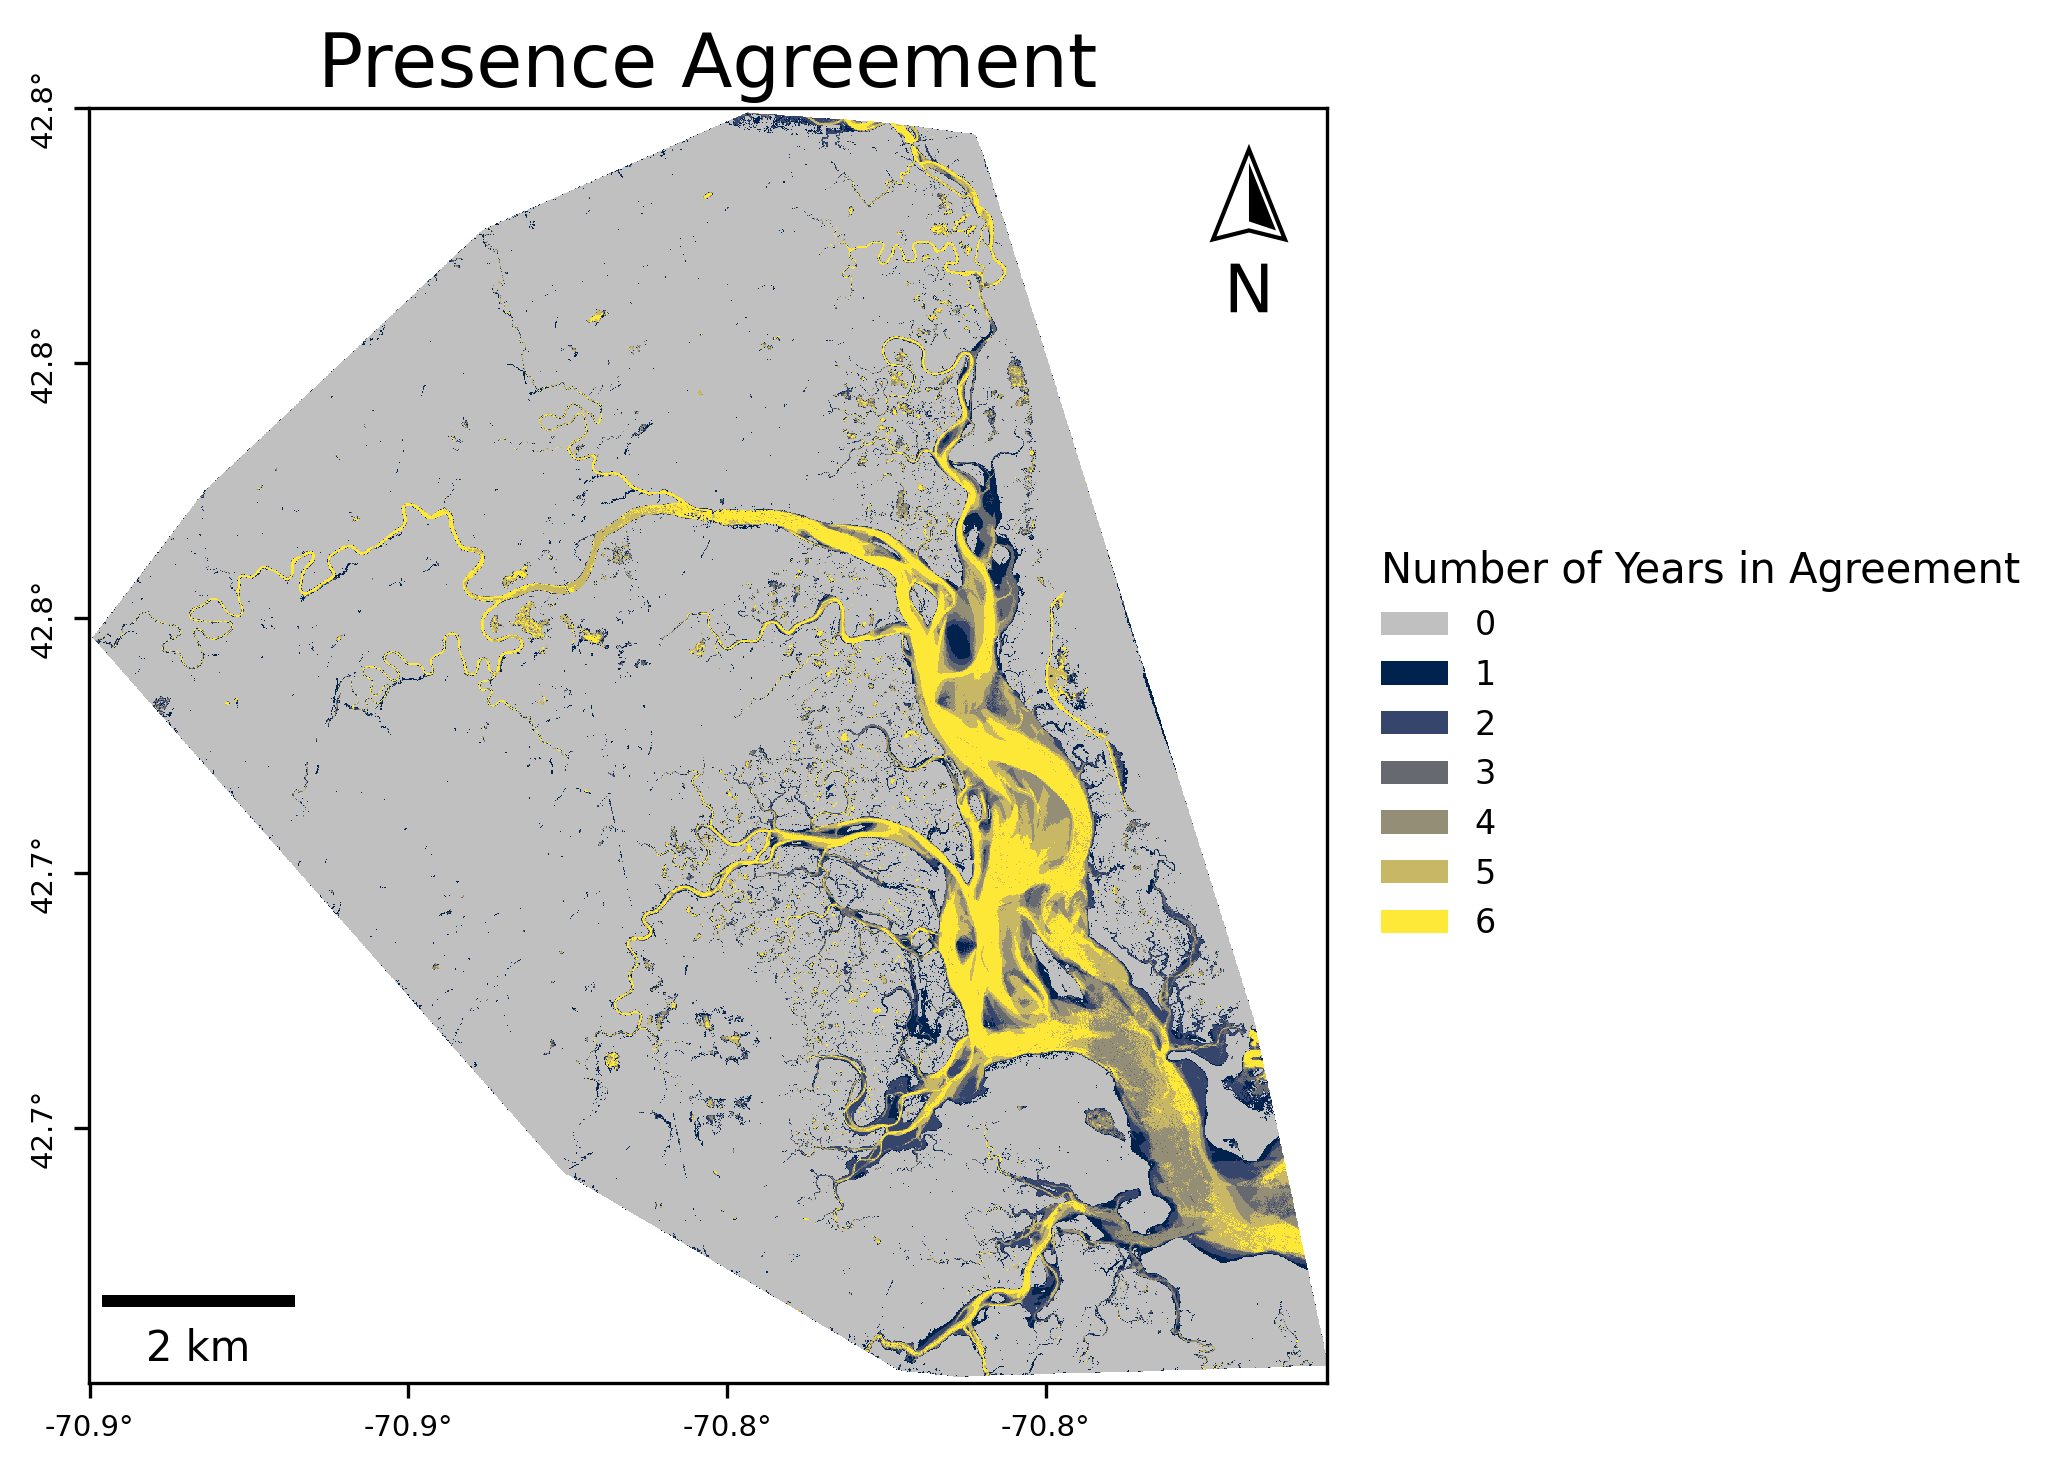

Map successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/maps/map_presence_hits.png


In [12]:
#import os
#import gc
#import numpy as np
#import rasterio
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mticker
#from matplotlib.colors import ListedColormap, BoundaryNorm
#from matplotlib.ticker import FuncFormatter
#from matplotlib.patches import Patch
#from matplotlib_scalebar.scalebar import ScaleBar
#from matplotlib_map_utils import north_arrow
#from pyproj import Transformer
# @title 5.2.2.1 Presence Agreement
def plot_presence_hits_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str = "presence_map_A_hits.tif",
    max_display_dim: int = 2000
) -> None:
    """
    Plot the Presence Hits map using a discrete integer scale.

    The visualization represents areas of agreement between time series.
    Value 0 is shown in gray, while values >= 1 follow a cividis gradient.
    This version uses downsampling to optimize memory usage for large rasters.

    Parameters
    ----------
    output_dir : str
        The directory path containing the input raster file.
    nodata_val : int
        The NoData value to mask out.
    raster_filename : str, optional
        The filename of the raster to be plotted.
        Default is "presence_map_A_hits.tif".
    max_display_dim : int, optional
        Maximum dimension (width or height) in pixels for the display
        grid to optimize RAM usage. Default is 2000.

    Returns
    -------
    None
    """
    # 1. Input Validation and Path Setup
    rasters_dir = os.path.join(
        output_dir,
        "rasters"
    )
    raster_path = os.path.join(
        rasters_dir,
        raster_filename
    )

    if not os.path.exists(
        raster_path
    ):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}"
        )

    print(
        f"Reading Presence Hits map for plotting: {raster_path}"
    )

    # 2. Data Loading with Downsampling
    with rasterio.open(
        raster_path
    ) as src:
        # Calculate scaling factor to stay under the pixel limit
        scale_factor = max_display_dim / max(
            src.width,
            src.height
        )

        if scale_factor > 1:
            scale_factor = 1.0

        out_shape = (
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        )

        print(
            f"Loading raster with downsampling factor: {scale_factor:.2f}"
        )

        # Read data using nearest neighbor to preserve integer classes
        data = src.read(
            1,
            out_shape=out_shape,
            resampling=rasterio.enums.Resampling.nearest
        )

        # Adjust transform for coordinate labels and scale bar accuracy
        transform = src.transform * src.transform.scale(
            (src.width / data.shape[1]),
            (src.height / data.shape[0])
        )

        src_crs = src.crs
        data_masked = np.ma.masked_equal(
            data,
            nodata_val
        )

    # Compute pixel size for scale bar based on display resolution
    pixel_size_m = compute_display_pixel_size_m(
        raster_path=raster_path,
        downsample_divisor=int(1 / scale_factor) if scale_factor < 1 else 1
    )

    # 3. Discrete Colormap Configuration
    data_max = int(
        data_masked.max()
    )

    if data_max == 0:
        data_max = 1

    # 'cividis' transitions from dark blue to yellow
    original_cmap = plt.get_cmap(
        "cividis"
    )

    colors_list = ["#c0c0c0"] + [
        original_cmap(i) for i in np.linspace(0, 1, data_max)
    ]

    cmap = ListedColormap(
        colors_list
    )

    # Define boundaries for integer bins
    bounds = np.arange(
        0,
        data_max + 2
    )
    norm = BoundaryNorm(
        bounds,
        cmap.N
    )

    # 4. Plotting the Figure
    fig, ax = plt.subplots(
        figsize=(8, 5),
        dpi=300
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.05
    )

    im = ax.imshow(
        data_masked,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    # 5. Legend Configuration
    present_values = np.unique(
        data_masked.compressed()
    )

    legend_elements = [
        Patch(
            facecolor=cmap(norm(i)),
            edgecolor="none",
            label=str(i)
        ) for i in range(0, data_max + 1) if i in present_values
    ]

    ax.legend(
        handles=legend_elements,
        title="Number of Years in Agreement",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8,
        title_fontsize=10,
        alignment="left"
    )

    # 6. Cartographic Elements
    scalebar = ScaleBar(
        pixel_size_m,
        units="m",
        length_fraction=0.35,
        location="lower left",
        box_alpha=0.0
    )
    ax.add_artist(
        scalebar
    )

    north_arrow(
        ax,
        location="upper right",
        shadow=False,
        scale=0.3
    )

    # 7. Axes Styling and Coordinate Formatting
    ax.set_title(
        "Presence Agreement",
        fontsize=18,
        pad=5
    )
    ax.set_aspect(
        "equal"
    )

    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    height, width = data.shape

    def format_lon(x, pos):
        x = np.clip(x, 0, width - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, height // 2, x)
        lon, _ = to_latlon.transform(x_proj, y_proj)
        return f"{lon:.1f}°"

    def format_lat(y, pos):
        y = np.clip(y, 0, height - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, y, width // 2)
        _, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lat:.1f}°"

    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    ax.tick_params(axis="both", labelsize=7, pad=4)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center")

    # 8. Saving and Cleaning Up
    maps_dir = os.path.join(
        output_dir,
        "maps"
    )
    os.makedirs(
        maps_dir,
        exist_ok=True
    )

    output_figure_path = os.path.join(
        maps_dir,
        "map_presence_hits.png"
    )

    plt.savefig(
        output_figure_path,
        dpi=300,
        format="png"
    )
    plt.show()

    print(
        f"Map successfully saved to: {output_figure_path}"
    )

    # Explicit memory cleanup
    del data
    del data_masked
    gc.collect()

# Execute the function
plot_presence_hits_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="presence_map_A_hits.tif"
)

Loading raster with downsampling factor: 0.09


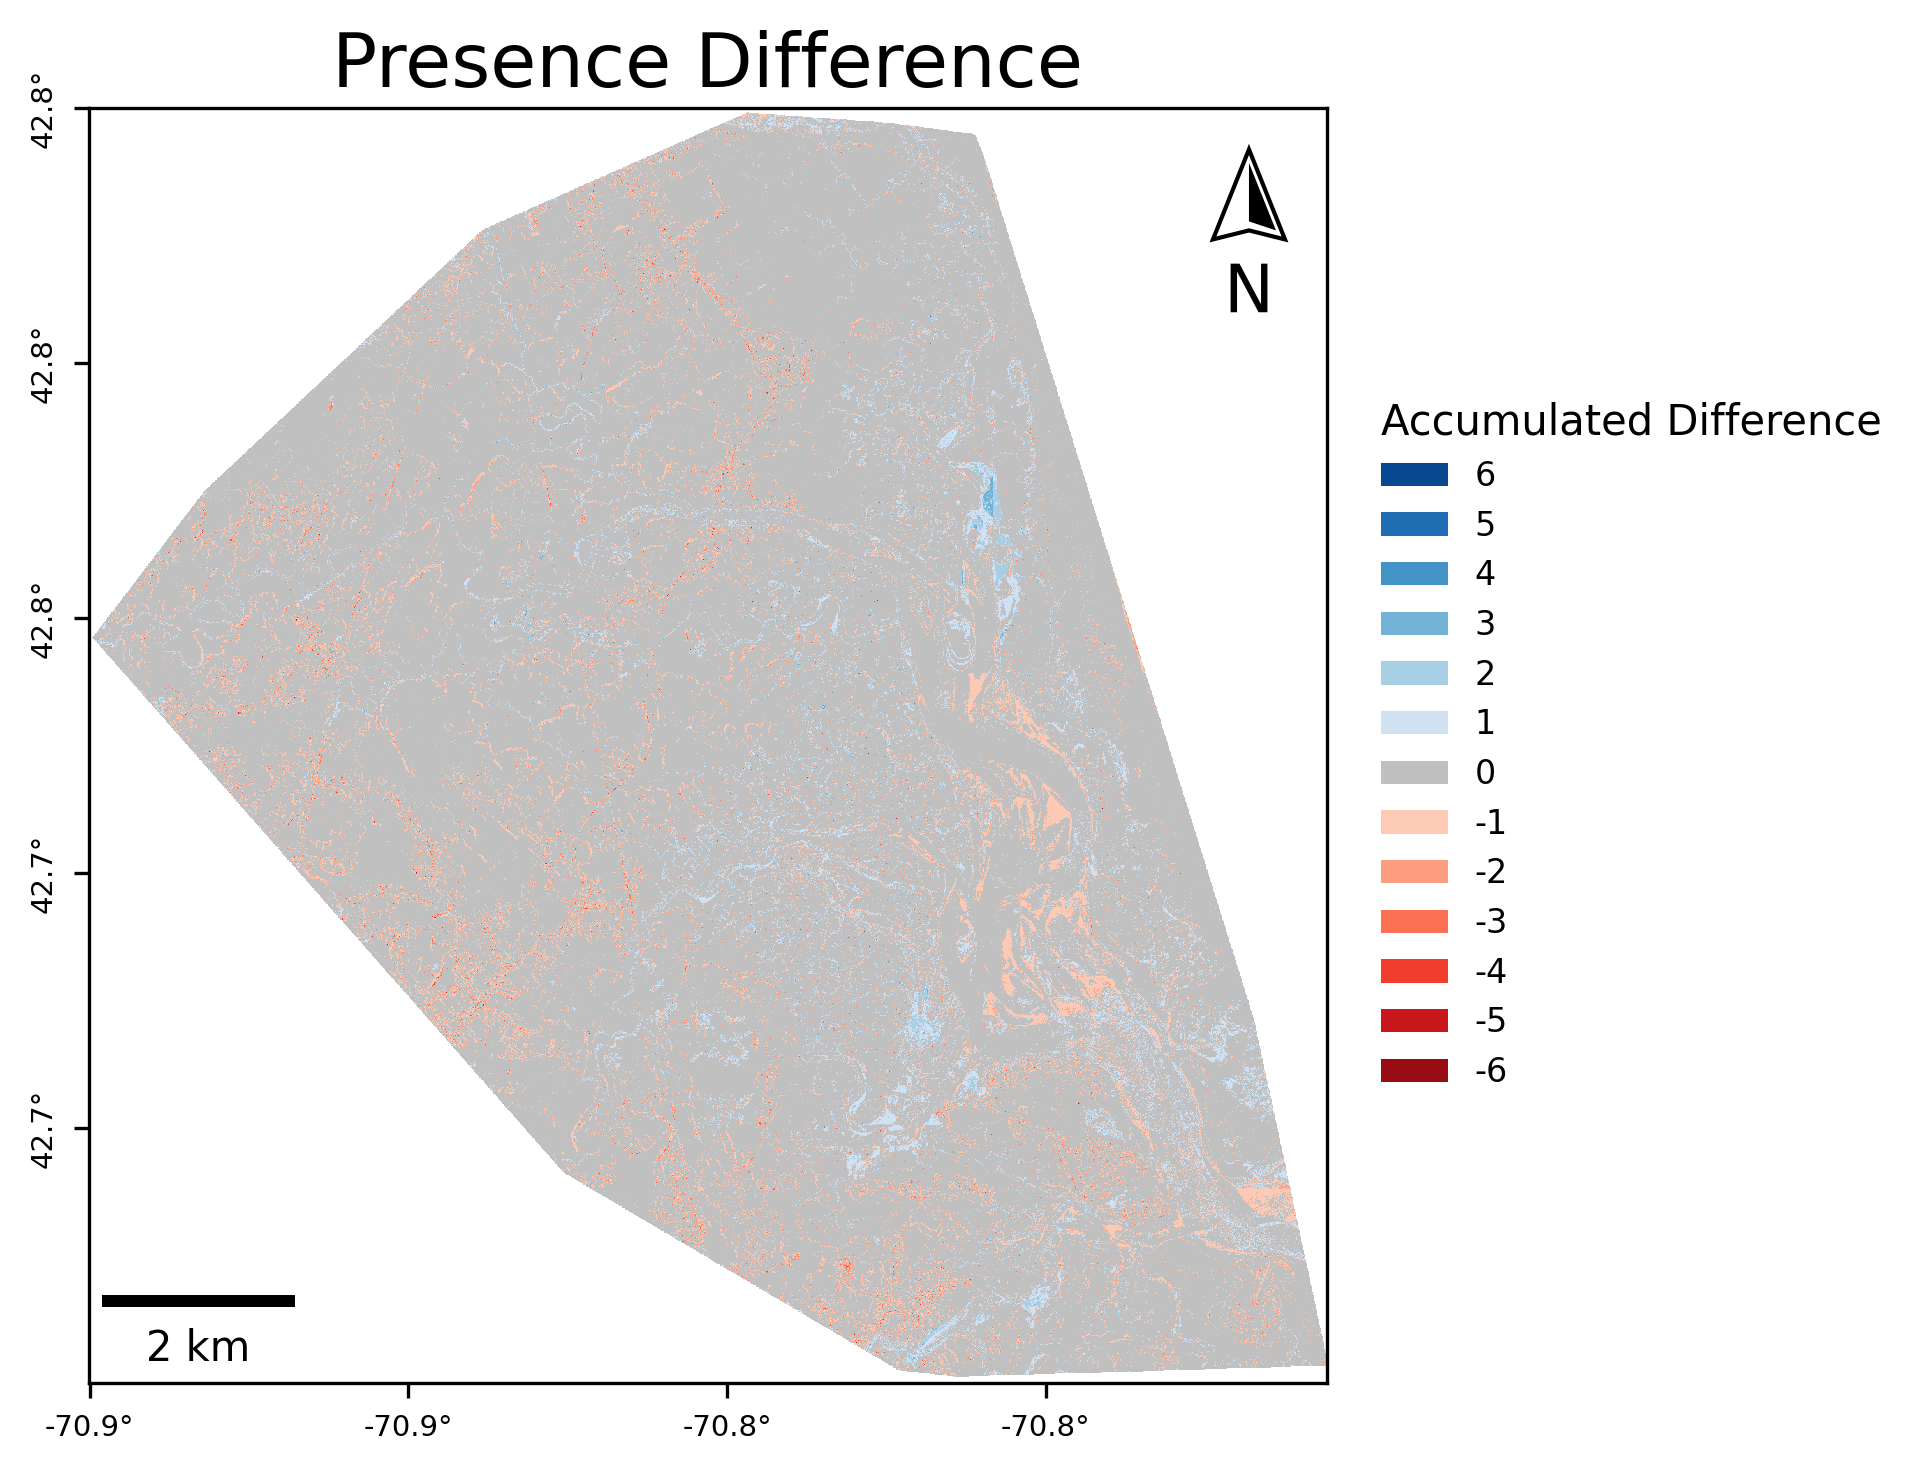

Map saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/maps/map_presence_difference.png


In [13]:
#import os
#import gc
#import numpy as np
#import rasterio
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mticker
#from matplotlib.colors import ListedColormap, BoundaryNorm
#from matplotlib.ticker import FuncFormatter
#from matplotlib.patches import Patch
#from matplotlib_scalebar.scalebar import ScaleBar
#from matplotlib_map_utils import north_arrow
#from pyproj import Transformer
# @title 5.1.2.2 Presence Difference
def plot_presence_difference_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str = "presence_map_B_difference.tif",
    max_display_dim: int = 2000
) -> None:
    """
    Plot the Presence Difference map using a diverging discrete scale.

    This version implements automatic downsampling to prevent memory
    exhaustion (Kernel Crash) when handling large rasters. It adjusts the
    spatial transform to ensure cartographic accuracy.

    Parameters
    ----------
    output_dir : str
        Directory where the 'rasters' and 'maps' folders are located.
    nodata_val : int
        Pixel value indicating no data.
    raster_filename : str, optional
        Filename of the raster to be plotted.
        Default is "presence_map_B_difference.tif".
    max_display_dim : int, optional
        Maximum dimension (width or height) in pixels for the display
        grid to optimize RAM usage. Default is 2000.

    Returns
    -------
    None
    """
    # 1. Path Setup
    rasters_dir = os.path.join(
        output_dir,
        "rasters"
    )
    raster_path = os.path.join(
        rasters_dir,
        raster_filename
    )

    if not os.path.exists(
        raster_path
    ):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}"
        )

    # 2. Data Loading with Downsampling
    with rasterio.open(
        raster_path
    ) as src:
        # Calculate scaling factor to stay under memory limits
        # We use nearest neighbor resampling for categorical/integer data
        scale_factor = max_display_dim / max(
            src.width,
            src.height
        )

        if scale_factor > 1:
            scale_factor = 1.0

        out_shape = (
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        )

        print(
            f"Loading raster with downsampling factor: {scale_factor:.2f}"
        )

        data = src.read(
            1,
            out_shape=out_shape,
            resampling=rasterio.enums.Resampling.nearest
        )

        # Update transform to maintain correct spatial referencing
        # for coordinate labels and scale bar
        transform = src.transform * src.transform.scale(
            (src.width / data.shape[1]),
            (src.height / data.shape[0])
        )

        src_crs = src.crs
        data_masked = np.ma.masked_equal(
            data,
            nodata_val
        )

    # Calculate pixel size for the scale bar based on downsampled grid
    pixel_size_m = compute_display_pixel_size_m(
        raster_path=raster_path,
        downsample_divisor=int(1 / scale_factor) if scale_factor < 1 else 1
    )

    # 3. Color Map and Range Configuration
    data_max = int(
        data_masked.max()
    )
    data_min = int(
        data_masked.min()
    )

    # Safety bounds for empty maps
    if data_max < 1:
        data_max = 1
    if data_min > -1:
        data_min = -1

    colors_dict = {
        0: "#c0c0c0"
    }

    # Red gradient for negative values
    red_cmap = plt.get_cmap(
        "Reds"
    )
    red_colors = red_cmap(
        np.linspace(
            0.2,
            0.9,
            abs(data_min)
        )
    )
    for i, val in enumerate(
        range(-1, data_min - 1, -1)
    ):
        colors_dict[val] = red_colors[i]

    # Blue gradient for positive values
    blue_cmap = plt.get_cmap(
        "Blues"
    )
    blue_colors = blue_cmap(
        np.linspace(
            0.2,
            0.9,
            data_max
        )
    )
    for i, val in enumerate(
        range(1, data_max + 1)
    ):
        colors_dict[val] = blue_colors[i]

    all_vals = np.arange(
        data_min,
        data_max + 1
    )
    colors_list = [
        colors_dict.get(v, "#000000") for v in all_vals
    ]
    cmap = ListedColormap(
        colors_list
    )

    bounds = np.arange(
        data_min - 0.5,
        data_max + 1.5,
        1
    )
    norm = BoundaryNorm(
        bounds,
        cmap.N
    )

    # 4. Plotting
    fig, ax = plt.subplots(
        figsize=(8, 5),
        dpi=300
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.05
    )

    im = ax.imshow(
        data_masked,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    # 5. Legend
    # np.unique on a downsampled array is much faster
    present_values = np.unique(
        data_masked.compressed()
    )
    present_values_sorted = np.sort(
        present_values
    )[::-1]

    legend_elements = [
        Patch(
            facecolor=colors_dict.get(val, "#000"),
            edgecolor="none",
            label=str(val)
        ) for val in present_values_sorted
    ]

    ax.legend(
        handles=legend_elements,
        title="Accumulated Difference",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8,
        title_fontsize=10,
        alignment="left"
    )

    # 6. Cartographic Elements
    scalebar = ScaleBar(
        pixel_size_m,
        units="m",
        length_fraction=0.35,
        location="lower left",
        box_alpha=0.0
    )
    ax.add_artist(
        scalebar
    )

    north_arrow(
        ax,
        location="upper right",
        shadow=False,
        scale=0.3
    )

    # 7. Axes Styling
    ax.set_title(
        "Presence Difference",
        fontsize=18,
        pad=5
    )
    ax.set_aspect(
        "equal"
    )

    # Formatter for Lat/Lon using the updated downsampled transform
    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    height, width = data.shape

    def format_lon(x, pos):
        x = np.clip(x, 0, width - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, height // 2, x)
        lon, _ = to_latlon.transform(x_proj, y_proj)
        return f"{lon:.1f}°"

    def format_lat(y, pos):
        y = np.clip(y, 0, height - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, y, width // 2)
        _, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lat:.1f}°"

    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    ax.tick_params(axis="both", labelsize=7, pad=4)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center")

    # 8. Saving and Cleaning Up
    maps_dir = os.path.join(output_dir, "maps")
    os.makedirs(maps_dir, exist_ok=True)
    output_figure_path = os.path.join(maps_dir, "map_presence_difference.png")

    plt.savefig(
        output_figure_path,
        dpi=300,
        format="png"
    )
    plt.show()

    # Explicit memory cleanup
    print(f"Map saved to: {output_figure_path}")
    del data
    del data_masked
    gc.collect()

# Execute
plot_presence_difference_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="presence_map_B_difference.tif"
)

Reading Temporal Allocation map (Downsampling: 0.09)


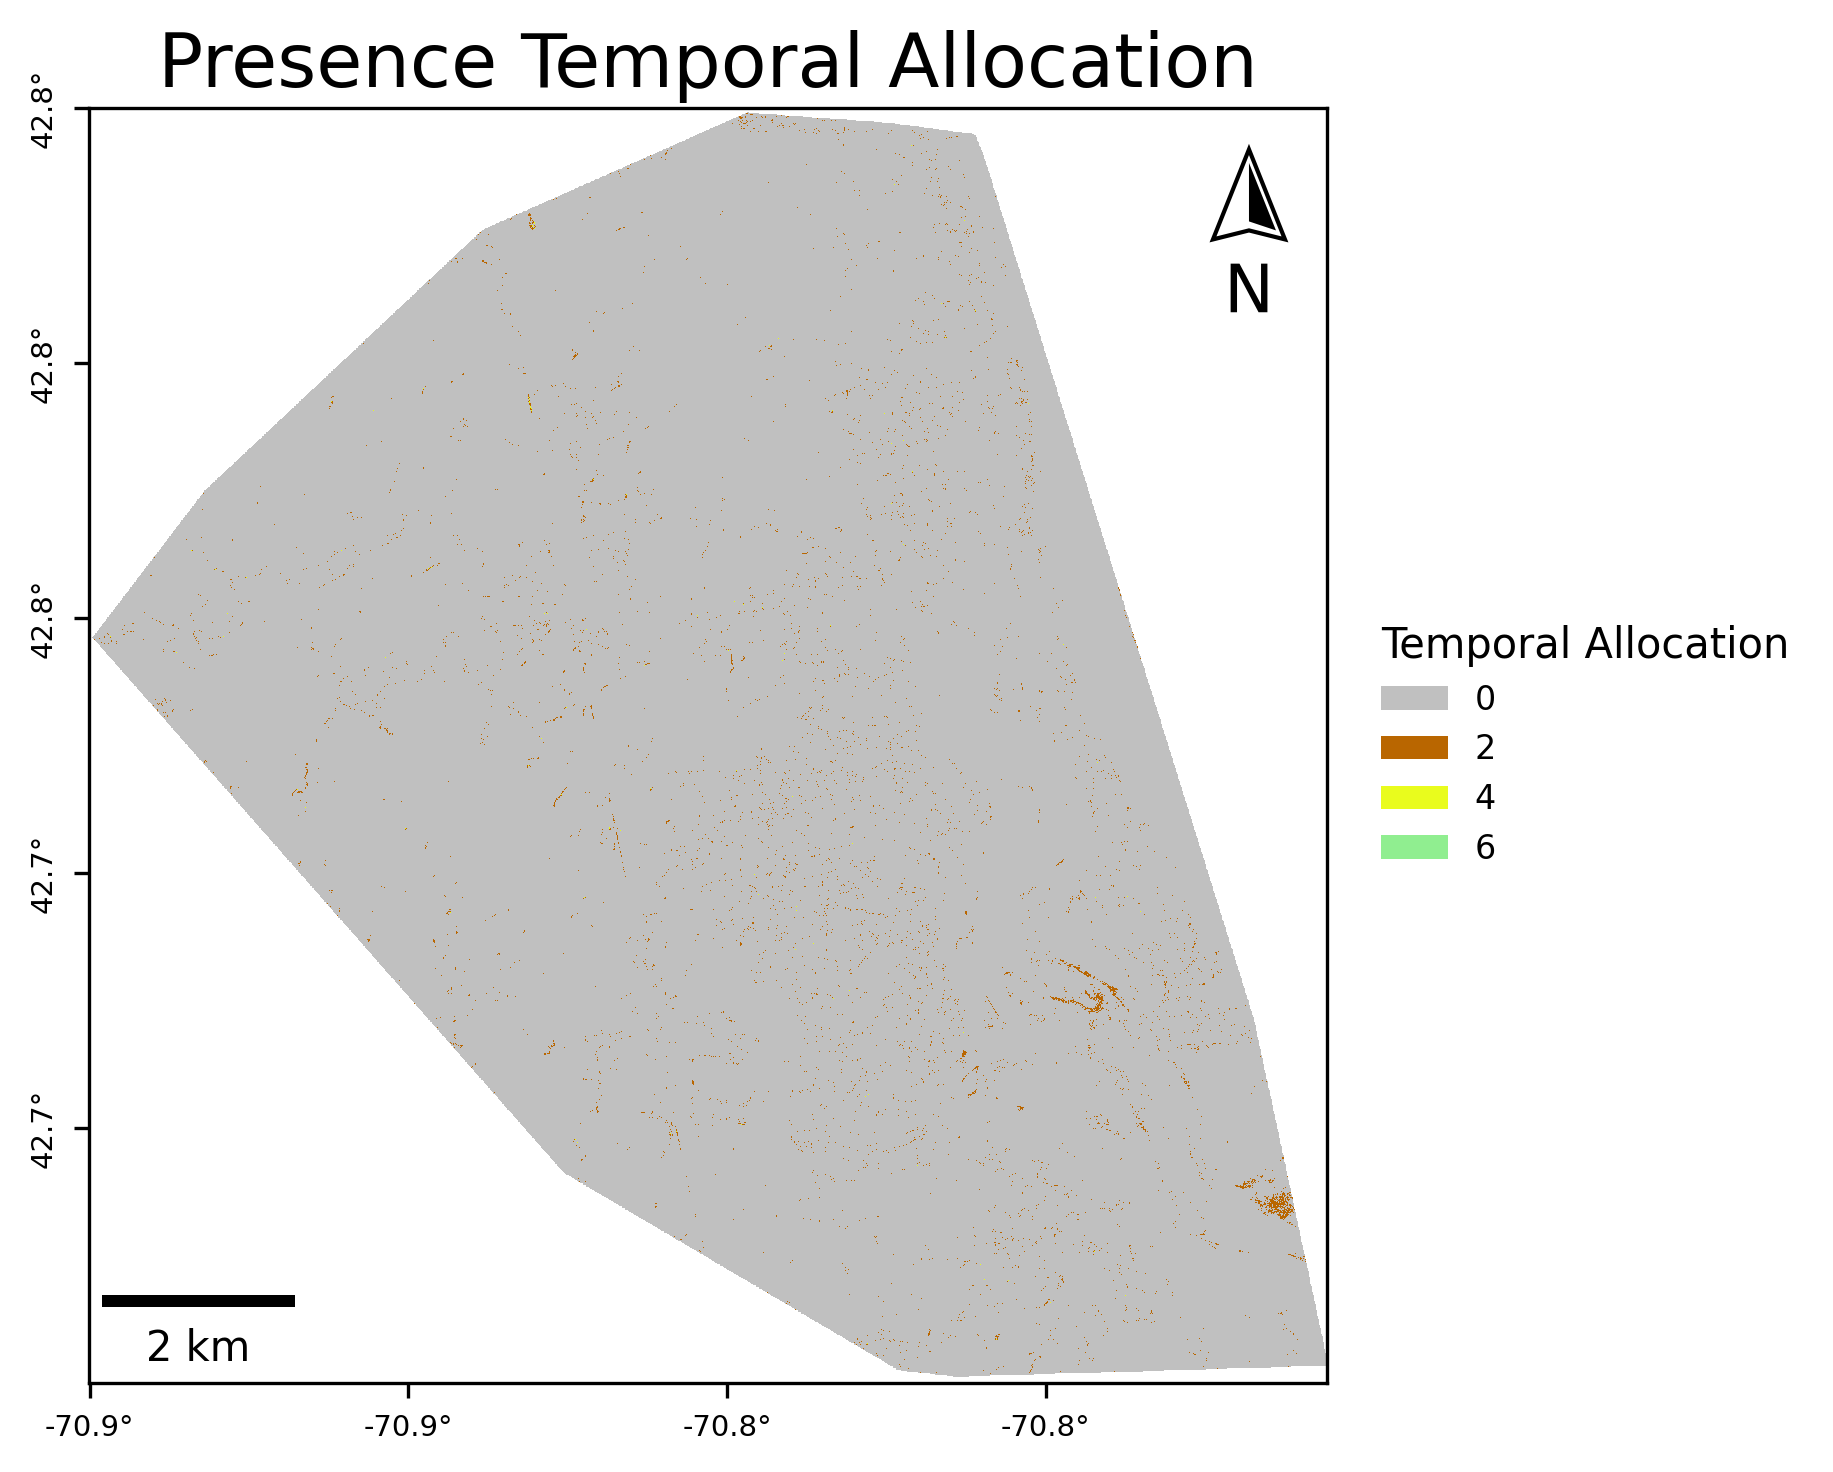

Map successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/maps/map_presence_temporal_allocation.png


In [8]:
#import os
#import gc
#import numpy as np
#import rasterio
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mticker
#from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
#from matplotlib.ticker import FuncFormatter
#from matplotlib.patches import Patch
#from matplotlib_scalebar.scalebar import ScaleBar
#from matplotlib_map_utils import north_arrow
#from pyproj import Transformer
# @title 5.1.2.3 Temporal Allocation of Presence
def plot_presence_temporal_allocation_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str = "presence_map_C_temporal_allocation.tif",
    max_display_dim: int = 2000
) -> None:
    """
    Plot the Presence Temporal Allocation map using a discrete scale.

    This function implements automatic downsampling to handle large raster
    extents efficiently. It uses a custom Red-Yellow-Green gradient to
    highlight areas of temporal disagreement.

    Parameters
    ----------
    output_dir : str
        Directory where the 'rasters' and 'maps' folders are located.
    nodata_val : int
        Pixel value indicating no data.
    raster_filename : str, optional
        Filename of the raster to be plotted.
        Default is "presence_map_C_temporal_allocation.tif".
    max_display_dim : int, optional
        Maximum dimension (width or height) in pixels for the display
        grid to optimize RAM usage. Default is 2000.

    Returns
    -------
    None
    """
    # 1. Path Setup
    rasters_dir = os.path.join(
        output_dir,
        "rasters"
    )
    raster_path = os.path.join(
        rasters_dir,
        raster_filename
    )

    if not os.path.exists(
        raster_path
    ):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}"
        )

    # 2. Data Loading with Downsampling
    with rasterio.open(
        raster_path
    ) as src:
        # Calculate scale factor to keep dimensions under max_display_dim
        scale_factor = max_display_dim / max(
            src.width,
            src.height
        )

        if scale_factor > 1:
            scale_factor = 1.0

        out_shape = (
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        )

        print(
            f"Reading Temporal Allocation map (Downsampling: {scale_factor:.2f})"
        )

        # Read data with nearest neighbor to preserve integer classes
        data = src.read(
            1,
            out_shape=out_shape,
            resampling=rasterio.enums.Resampling.nearest
        )

        # Adjust transform for the downsampled grid to maintain spatial accuracy
        transform = src.transform * src.transform.scale(
            (src.width / data.shape[1]),
            (src.height / data.shape[0])
        )

        src_crs = src.crs
        data_masked = np.ma.masked_equal(
            data,
            nodata_val
        )

    # Calculate pixel size for the scale bar based on the display grid
    pixel_size_m = compute_display_pixel_size_m(
        raster_path=raster_path,
        downsample_divisor=int(1 / scale_factor) if scale_factor < 1 else 1
    )

    # 3. Colormap and Range Configuration
    data_max = int(
        data_masked.max()
    )

    if data_max < 1:
        data_max = 1

    colors_dict = {
        0: "#c0c0c0"
    }

    # Create custom gradient: Dark Red -> Yellow -> Light Green
    pos_cmap = LinearSegmentedColormap.from_list(
        "red_yellow_green",
        [
            "#8b0000",
            "#ffff00",
            "#90ee90"
        ]
    )

    for i, val in enumerate(
        range(1, data_max + 1)
    ):
        frac = i / (data_max - 1) if data_max > 1 else 0.5
        colors_dict[val] = pos_cmap(frac)

    colors_list = [
        colors_dict.get(v, "#000000") for v in range(data_max + 1)
    ]
    cmap = ListedColormap(
        colors_list
    )

    # Discrete boundaries for integer steps
    bounds = np.arange(
        -0.5,
        data_max + 1.5,
        1
    )
    norm = BoundaryNorm(
        bounds,
        cmap.N
    )

    # 4. Plotting the Figure
    fig, ax = plt.subplots(
        figsize=(8, 5),
        dpi=300
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.05
    )

    im = ax.imshow(
        data_masked,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    # 5. Legend Configuration
    present_values = np.unique(
        data_masked.compressed()
    )
    present_values_sorted = np.sort(
        present_values
    )

    legend_elements = [
        Patch(
            facecolor=colors_dict.get(val, "#000"),
            edgecolor="none",
            label=str(val)
        ) for val in present_values_sorted
    ]

    ax.legend(
        handles=legend_elements,
        title="Temporal Allocation",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8,
        title_fontsize=10,
        alignment="left"
    )

    # 6. Cartographic Elements
    scalebar = ScaleBar(
        pixel_size_m,
        units="m",
        length_fraction=0.35,
        location="lower left",
        box_alpha=0.0
    )
    ax.add_artist(
        scalebar
    )

    north_arrow(
        ax,
        location="upper right",
        shadow=False,
        scale=0.3
    )

    # 7. Axes and Coordinate Formatting
    ax.set_title(
        "Presence Temporal Allocation",
        fontsize=18,
        pad=5
    )
    ax.set_aspect(
        "equal"
    )

    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    height, width = data.shape

    def format_lon(x, pos):
        x = np.clip(x, 0, width - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, height // 2, x)
        lon, _ = to_latlon.transform(x_proj, y_proj)
        return f"{lon:.1f}°"

    def format_lat(y, pos):
        y = np.clip(y, 0, height - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, y, width // 2)
        _, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lat:.1f}°"

    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    ax.tick_params(axis="both", labelsize=7, pad=4)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center")

    # 8. Output and Cleanup
    maps_dir = os.path.join(output_dir, "maps")
    os.makedirs(maps_dir, exist_ok=True)
    output_figure_path = os.path.join(maps_dir, "map_presence_temporal_allocation.png")

    plt.savefig(
        output_figure_path,
        dpi=300,
        format="png"
    )
    plt.show()

    print(f"Map successfully saved to: {output_figure_path}")

    # Explicitly clear large arrays from memory
    del data
    del data_masked
    gc.collect()

# Execute the function
plot_presence_temporal_allocation_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="presence_map_C_temporal_allocation.tif"
)

### 5.2 Change Maps

In [14]:
# @title 5.2.1 Compute Change Maps
def generate_change_maps(
    ts_x_paths: List[str],
    ts_y_paths: List[str],
    output_dir: str,
    no_data_val: int = 255,
    presence_val: int = 1
) -> None:
    """
    Generates the three Change Maps (D, E, and F) based on the
    methodology by Pontius Jr. et al. (Equations 52, 53, 54).

    Parameters
    ----------
    ts_x_paths : List[str]
        List of file paths for Time Series X.
    ts_y_paths : List[str]
        List of file paths for Time Series Y.
    output_dir : str
        Directory where the output maps will be saved.
    no_data_val : int, optional
        Pixel value indicating no data, by default 255.
    presence_val : int, optional
        Pixel value indicating presence, by default 1.

    Returns
    -------
    None
    """
    maps_dir = os.path.join(output_dir, "rasters")
    os.makedirs(maps_dir, exist_ok=True)

    path_d = os.path.join(maps_dir, "change_map_D_hits.tif")
    path_e = os.path.join(maps_dir, "change_map_E_difference.tif")
    path_f = os.path.join(
        maps_dir,
        "change_map_F_temporal_allocation.tif"
    )

    num_times = len(ts_x_paths)

    with rasterio.open(ts_x_paths[0]) as src_ref:
        meta = src_ref.meta.copy()
        windows = [window for _, window in src_ref.block_windows()]

    # Use int16 to accommodate negative values safely and save space
    meta.update({
        'dtype': rasterio.int16,
        'nodata': no_data_val,
        'compress': 'deflate'
    })

    print("Generating Change Maps...")
    print(f"Map D: {path_d}")
    print(f"Map E: {path_e}")
    print(f"Map F: {path_f}")

    # Use ExitStack to manage multiple open files safely and efficiently
    with ExitStack() as stack:
        srcs_x = [
            stack.enter_context(rasterio.open(p)) for p in ts_x_paths
        ]
        srcs_y = [
            stack.enter_context(rasterio.open(p)) for p in ts_y_paths
        ]

        dst_d = stack.enter_context(rasterio.open(path_d, 'w', **meta))
        dst_e = stack.enter_context(rasterio.open(path_e, 'w', **meta))
        dst_f = stack.enter_context(rasterio.open(path_f, 'w', **meta))

        for window in tqdm(windows, desc="Processing Spatial Blocks"):
            height, width = window.height, window.width

            # Accumulators for D_n and F_n components
            d_n_sum = np.zeros((height, width), dtype=np.int16)
            abs_diff_sum = np.zeros((height, width), dtype=np.int16)
            valid_mask = np.ones((height, width), dtype=bool)

            # Read initial time (t=0)
            arr_x0 = srcs_x[0].read(1, window=window)
            arr_y0 = srcs_y[0].read(1, window=window)

            valid_mask &= (arr_x0 != no_data_val) & (arr_y0 != no_data_val)

            p_x0 = np.where(
                arr_x0 == presence_val, 1, 0
            ).astype(np.int16)
            p_y0 = np.where(
                arr_y0 == presence_val, 1, 0
            ).astype(np.int16)

            p_x_prev, p_y_prev = p_x0, p_y0

            # Process intervals
            for t in range(1, num_times):
                arr_x_t = srcs_x[t].read(1, window=window)
                arr_y_t = srcs_y[t].read(1, window=window)

                valid_mask &= (
                    (arr_x_t != no_data_val) & (arr_y_t != no_data_val)
                )

                p_x_curr = np.where(
                    arr_x_t == presence_val, 1, 0
                ).astype(np.int16)
                p_y_curr = np.where(
                    arr_y_t == presence_val, 1, 0
                ).astype(np.int16)

                delta_x = p_x_curr - p_x_prev
                delta_y = p_y_curr - p_y_prev

                gain_x = np.maximum(0, delta_x)
                gain_y = np.maximum(0, delta_y)
                loss_x = np.minimum(0, delta_x)
                loss_y = np.minimum(0, delta_y)

                g_hn = np.minimum(gain_x, gain_y)
                l_hn = np.maximum(loss_x, loss_y)

                # Eq 52: accumulate (Gh_n - Lh_n)
                d_n_sum += (g_hn - l_hn)

                # Eq 54 component: accumulate |Delta_Y - Delta_X|
                abs_diff_sum += np.abs(delta_y - delta_x)

                p_x_prev, p_y_prev = p_x_curr, p_y_curr

            # p_x_prev and p_y_prev are now P_x_final and P_y_final
            # Eq 53: E_n = (Y_final - Y_init) - (X_final - X_init)
            e_n = (p_y_prev - p_y0) - (p_x_prev - p_x0)

            # Eq 54: F_n = Sum(|Delta_Y - Delta_X|) - |E_n|
            f_n = abs_diff_sum - np.abs(e_n)

            # Mask no_data values
            out_d = np.where(valid_mask, d_n_sum, no_data_val)
            out_e = np.where(valid_mask, e_n, no_data_val)
            out_f = np.where(valid_mask, f_n, no_data_val)

            # Write to disk
            dst_d.write(out_d.astype(np.int16), 1, window=window)
            dst_e.write(out_e.astype(np.int16), 1, window=window)
            dst_f.write(out_f.astype(np.int16), 1, window=window)

    print("\nChange Maps generated successfully!")


# Execute the function
generate_change_maps(
    ts_x_paths=time_series_x,
    ts_y_paths=time_series_y,
    output_dir=output_path,
    no_data_val=no_data_value,
    presence_val=presence_value
)


Generating Change Maps...
Map D: /content/drive/MyDrive/Assessments/compare-time-series/extent2/rasters/change_map_D_hits.tif
Map E: /content/drive/MyDrive/Assessments/compare-time-series/extent2/rasters/change_map_E_difference.tif
Map F: /content/drive/MyDrive/Assessments/compare-time-series/extent2/rasters/change_map_F_temporal_allocation.tif


Processing Spatial Blocks:   0%|          | 0/22568 [00:00<?, ?it/s]


Change Maps generated successfully!


#### 5.2.2 Plot Change Maps

Reading Change Hits map for plotting: /content/drive/MyDrive/Assessments/compare-time-series/extent2/rasters/change_map_D_hits.tif
Loading raster with downsampling factor: 0.09


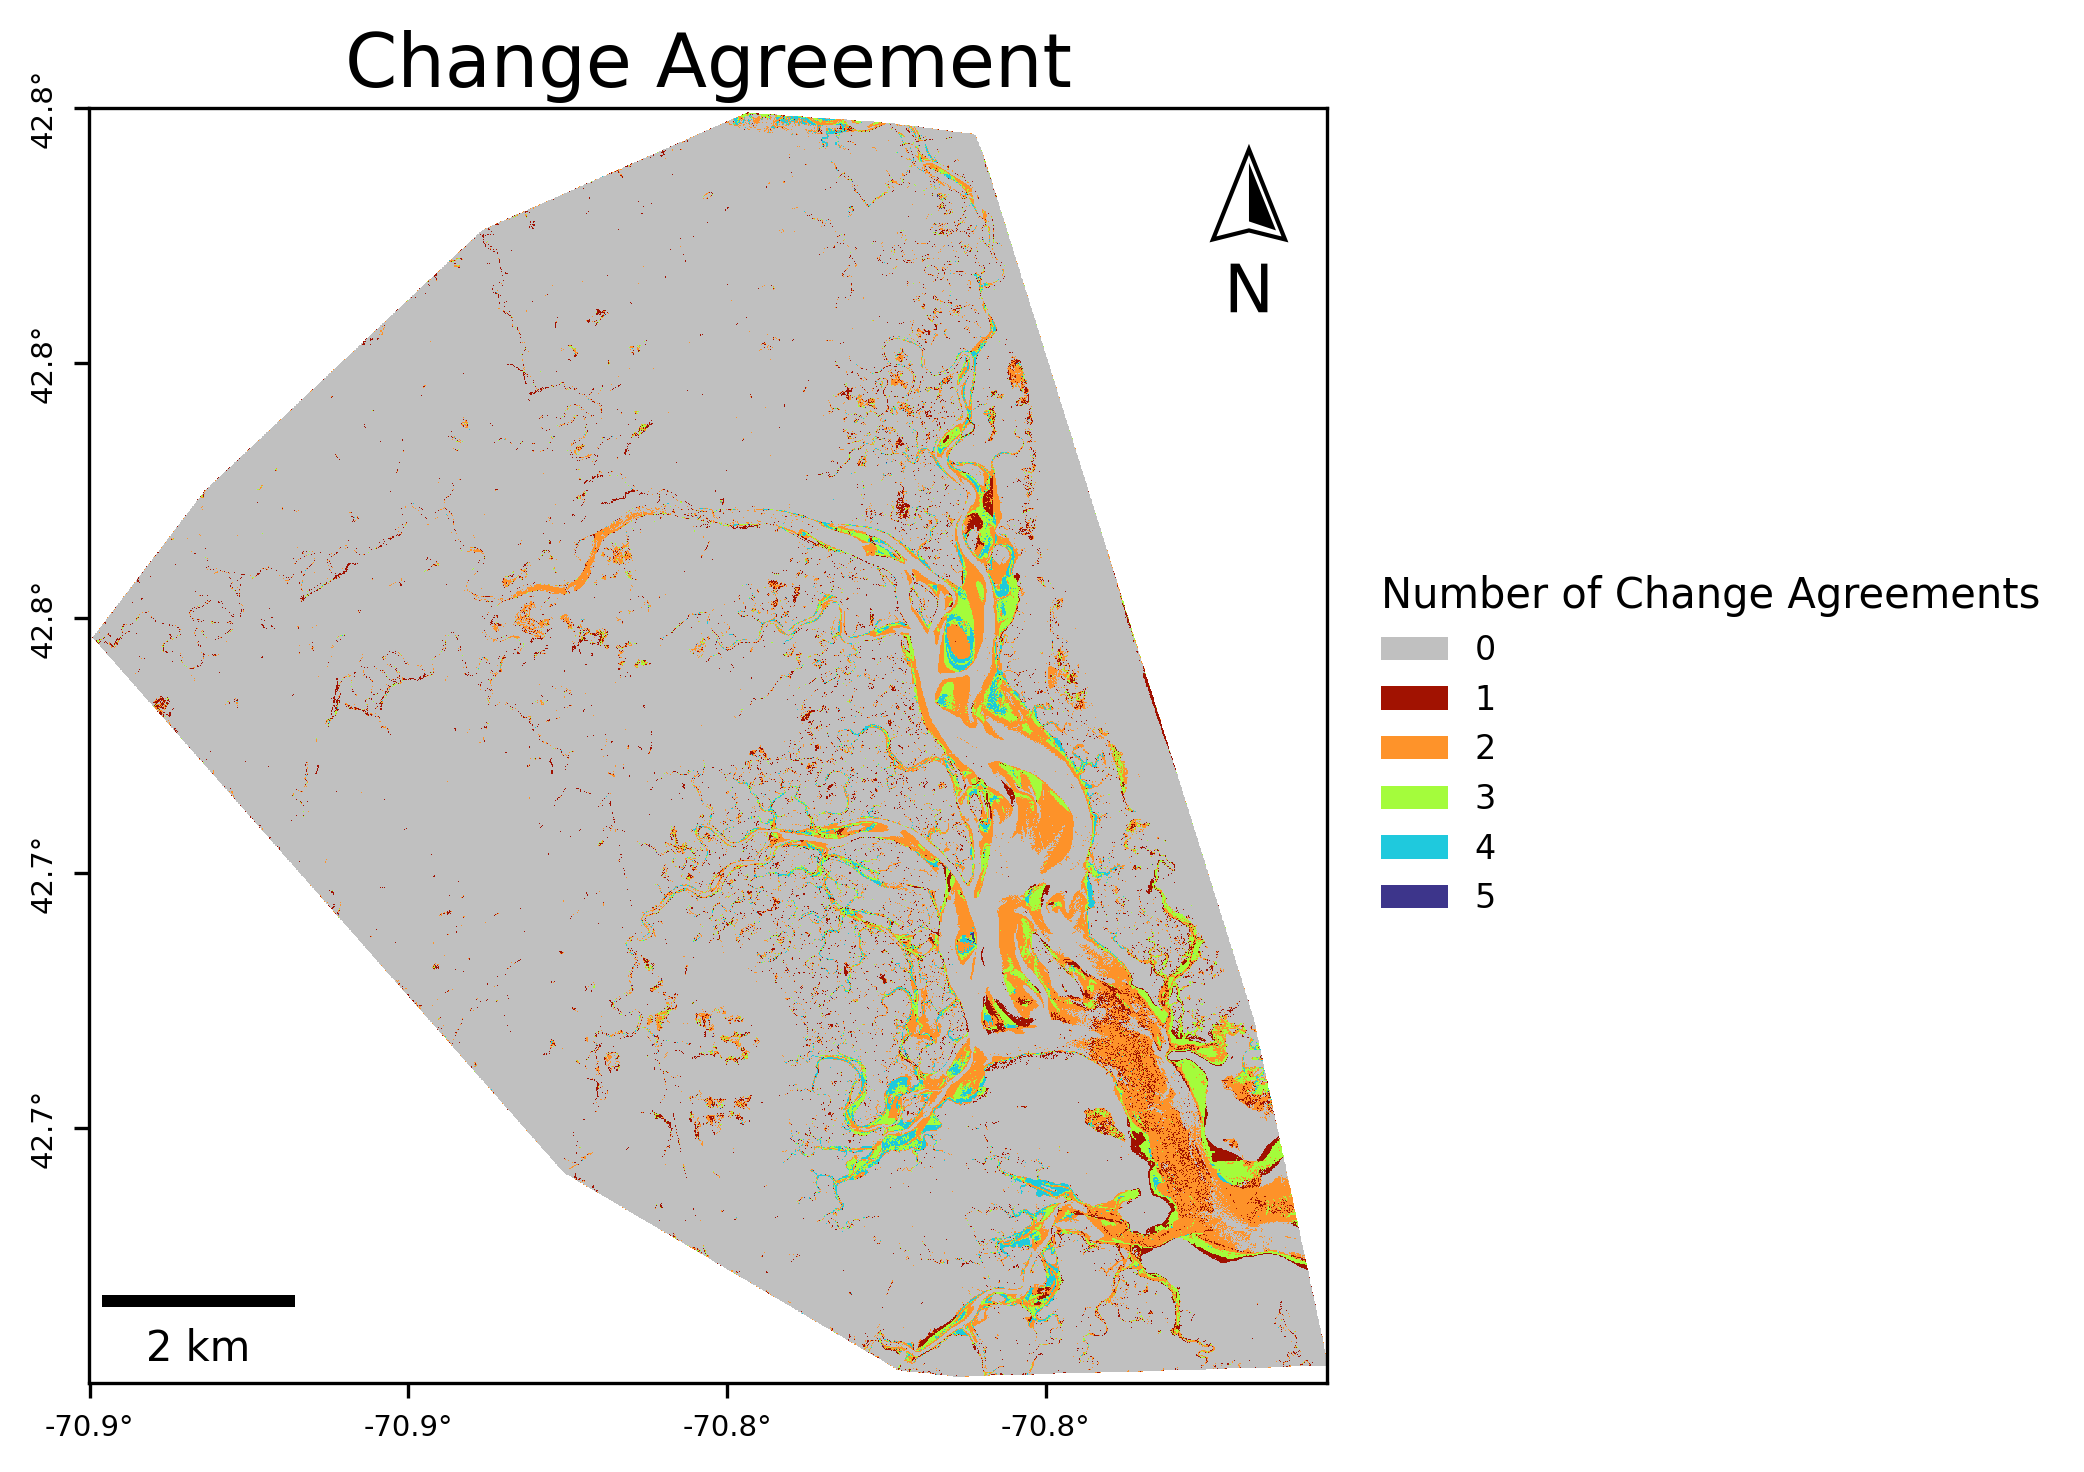

Map successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/maps/map_change_hits.png


In [15]:
#import os
#import gc
#import numpy as np
#import rasterio
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mticker
#from matplotlib.colors import ListedColormap, BoundaryNorm
#from matplotlib.ticker import FuncFormatter
#from matplotlib.patches import Patch
#from matplotlib_scalebar.scalebar import ScaleBar
#from matplotlib_map_utils import north_arrow
#from pyproj import Transformer

# @title 5.2.2.1 Change Agreement
def plot_change_hits_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str = "change_map_D_hits.tif",
    max_display_dim: int = 2000
) -> None:
    """
    Plot the Change Hits map using a discrete integer scale and turbo_r colormap.

    This function implements automatic downsampling to handle large raster
    extents, ensuring the Google Colab kernel remains stable. It represents
    change agreement with a turbo-style gradient and 0 in gray.

    Parameters
    ----------
    output_dir : str
        Directory where the 'rasters' and 'maps' folders are located.
    nodata_val : int
        Pixel value indicating no data.
    raster_filename : str, optional
        Filename of the raster to be plotted.
        Default is "change_map_D_hits.tif".
    max_display_dim : int, optional
        Maximum dimension (width or height) in pixels for the display
        grid to optimize RAM usage. Default is 2000.

    Returns
    -------
    None
    """
    # 1. Path Setup
    rasters_dir = os.path.join(
        output_dir,
        "rasters"
    )
    raster_path = os.path.join(
        rasters_dir,
        raster_filename
    )

    if not os.path.exists(
        raster_path
    ):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}"
        )

    print(
        f"Reading Change Hits map for plotting: {raster_path}"
    )

    # 2. Data Loading with Downsampling
    with rasterio.open(
        raster_path
    ) as src:
        # Calculate scale factor to stay within max_display_dim
        scale_factor = max_display_dim / max(
            src.width,
            src.height
        )

        if scale_factor > 1:
            scale_factor = 1.0

        out_shape = (
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        )

        print(
            f"Loading raster with downsampling factor: {scale_factor:.2f}"
        )

        # Read data with nearest neighbor to preserve discrete values
        data = src.read(
            1,
            out_shape=out_shape,
            resampling=rasterio.enums.Resampling.nearest
        )

        # Adjust spatial transform to maintain coordinate and scale accuracy
        transform = src.transform * src.transform.scale(
            (src.width / data.shape[1]),
            (src.height / data.shape[0])
        )

        src_crs = src.crs
        data_masked = np.ma.masked_equal(
            data,
            nodata_val
        )

    # Calculate pixel size for the scale bar based on the downsampled grid
    pixel_size_m = compute_display_pixel_size_m(
        raster_path=raster_path,
        downsample_divisor=int(1 / scale_factor) if scale_factor < 1 else 1
    )

    # 3. Determine Range and Colormap Configuration
    data_max = int(
        data_masked.max()
    )
    data_min = int(
        data_masked.min()
    )

    # Safe bounds for indexing
    if data_max < 1:
        data_max = 1
    if data_min > 0:
        data_min = 0

    colors_dict = {
        0: "#c0c0c0"
    }

    # Positive values: inverted turbo scale
    cmap_turbo = plt.get_cmap(
        "turbo_r"
    )
    pos_colors = cmap_turbo(
        np.linspace(
            0.05,
            0.95,
            data_max
        )
    )
    for i, val in enumerate(
        range(1, data_max + 1)
    ):
        colors_dict[val] = pos_colors[i]

    # Handle negative values if present
    if data_min < 0:
        for val in range(data_min, 0):
            colors_dict[val] = "#000000"

    # Build colormap from dictionary
    all_vals = np.arange(
        data_min,
        data_max + 1
    )
    colors_list = [
        colors_dict.get(v, "#000000") for v in all_vals
    ]
    cmap = ListedColormap(
        colors_list
    )

    # Boundaries for integer normalization
    bounds = np.arange(
        data_min - 0.5,
        data_max + 1.5,
        1
    )
    norm = BoundaryNorm(
        bounds,
        cmap.N
    )

    # 4. Plotting the Figure
    fig, ax = plt.subplots(
        figsize=(8, 5),
        dpi=300
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.05
    )

    im = ax.imshow(
        data_masked,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    # 5. Legend Configuration
    present_values = np.unique(
        data_masked.compressed()
    )
    present_values_sorted = np.sort(
        present_values
    )

    legend_elements = [
        Patch(
            facecolor=colors_dict.get(val, "#000"),
            edgecolor="none",
            label=str(val)
        ) for val in present_values_sorted
    ]

    ax.legend(
        handles=legend_elements,
        title="Number of Change Agreements",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8,
        title_fontsize=10,
        alignment="left"
    )

    # 6. Cartographic Elements
    scalebar = ScaleBar(
        pixel_size_m,
        units="m",
        length_fraction=0.35,
        location="lower left",
        box_alpha=0.0
    )
    ax.add_artist(
        scalebar
    )

    north_arrow(
        ax,
        location="upper right",
        shadow=False,
        scale=0.3
    )

    # 7. Axes and Coordinate Styling
    ax.set_title(
        "Change Agreement",
        fontsize=18,
        pad=5
    )
    ax.set_aspect(
        "equal"
    )

    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    height, width = data.shape

    def format_lon(x, pos):
        x = np.clip(x, 0, width - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, height // 2, x)
        lon, _ = to_latlon.transform(x_proj, y_proj)
        return f"{lon:.1f}°"

    def format_lat(y, pos):
        y = np.clip(y, 0, height - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, y, width // 2)
        _, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lat:.1f}°"

    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    ax.tick_params(axis="both", labelsize=7, pad=4)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center")

    # 8. Output and Memory Cleanup
    maps_dir = os.path.join(output_dir, "maps")
    os.makedirs(maps_dir, exist_ok=True)
    output_figure_path = os.path.join(maps_dir, "map_change_hits.png")

    plt.savefig(
        output_figure_path,
        dpi=300,
        format="png"
    )
    plt.show()

    print(f"Map successfully saved to: {output_figure_path}")

    # Clean up large arrays to free RAM
    del data
    del data_masked
    gc.collect()

# Execute the function
plot_change_hits_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="change_map_D_hits.tif"
)

Reading Change Difference map for plotting: /content/drive/MyDrive/Assessments/compare-time-series/extent2/rasters/change_map_E_difference.tif
Loading raster with downsampling factor: 0.09


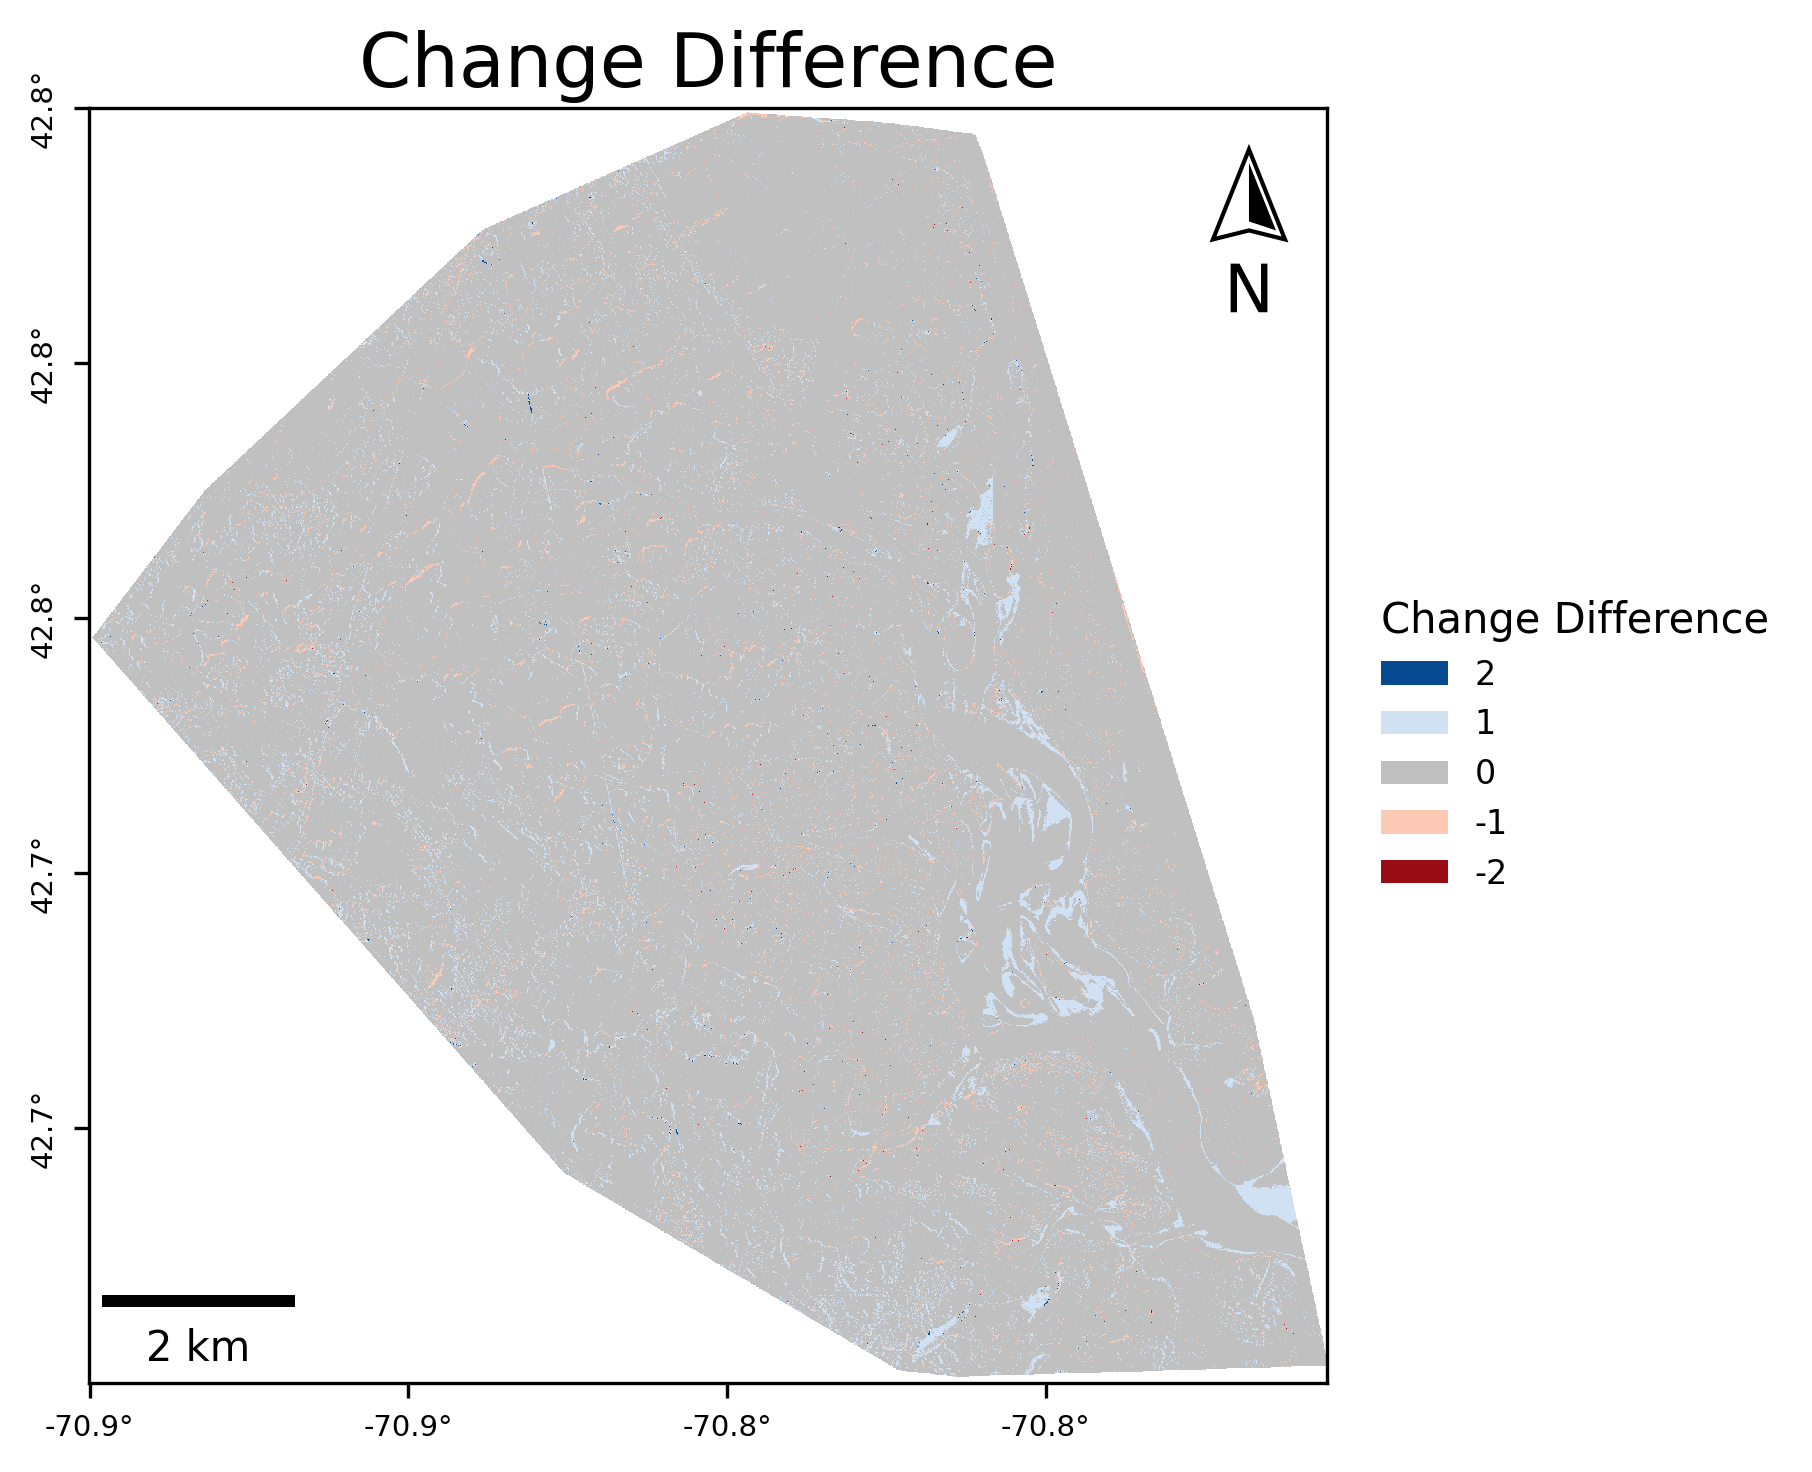

Map successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/maps/map_change_difference.png


In [16]:
#import os
#import gc
#import numpy as np
#import rasterio
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mticker
#from matplotlib.colors import ListedColormap, BoundaryNorm
#from matplotlib.ticker import FuncFormatter
#from matplotlib.patches import Patch
#from matplotlib_scalebar.scalebar import ScaleBar
#from matplotlib_map_utils import north_arrow
#from pyproj import Transformer

# @title 5.2.2.2 Change Difference
def plot_change_difference_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str = "change_map_E_difference.tif",
    max_display_dim: int = 2000
) -> None:
    """
    Plot the Change Difference map using a diverging discrete scale.

    This function implements automatic downsampling to handle large raster
    extents, ensuring the Google Colab kernel remains stable. It represents
    spatial differences in change magnitude with a diverging Red-Gray-Blue scale.

    Parameters
    ----------
    output_dir : str
        Directory where the 'rasters' and 'maps' folders are located.
    nodata_val : int
        Pixel value indicating no data.
    raster_filename : str, optional
        Filename of the raster to be plotted.
        Default is "change_map_E_difference.tif".
    max_display_dim : int, optional
        Maximum dimension (width or height) in pixels for the display
        grid to optimize RAM usage. Default is 2000.

    Returns
    -------
    None
    """
    # 1. Path Setup
    rasters_dir = os.path.join(
        output_dir,
        "rasters"
    )
    raster_path = os.path.join(
        rasters_dir,
        raster_filename
    )

    if not os.path.exists(
        raster_path
    ):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}"
        )

    print(
        f"Reading Change Difference map for plotting: {raster_path}"
    )

    # 2. Data Loading with Downsampling
    with rasterio.open(
        raster_path
    ) as src:
        # Calculate scale factor to stay within max_display_dim limit
        scale_factor = max_display_dim / max(
            src.width,
            src.height
        )

        if scale_factor > 1:
            scale_factor = 1.0

        out_shape = (
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        )

        print(
            f"Loading raster with downsampling factor: {scale_factor:.2f}"
        )

        # Read data using nearest neighbor to preserve integer differences
        data = src.read(
            1,
            out_shape=out_shape,
            resampling=rasterio.enums.Resampling.nearest
        )

        # Update spatial transform for the new grid resolution
        transform = src.transform * src.transform.scale(
            (src.width / data.shape[1]),
            (src.height / data.shape[0])
        )

        src_crs = src.crs
        data_masked = np.ma.masked_equal(
            data,
            nodata_val
        )

    # Compute pixel size for scale bar based on the display grid
    pixel_size_m = compute_display_pixel_size_m(
        raster_path=raster_path,
        downsample_divisor=int(1 / scale_factor) if scale_factor < 1 else 1
    )

    # 3. Determine Range and Colormap Configuration
    data_max = int(
        data_masked.max()
    )
    data_min = int(
        data_masked.min()
    )

    # Safety bounds for empty maps
    if data_max < 1:
        data_max = 1
    if data_min > -1:
        data_min = -1

    colors_dict = {
        0: "#c0c0c0"
    }

    # Red gradient for negative differences
    red_cmap = plt.get_cmap(
        "Reds"
    )
    red_colors = red_cmap(
        np.linspace(
            0.2,
            0.9,
            abs(data_min)
        )
    )
    for i, val in enumerate(
        range(-1, data_min - 1, -1)
    ):
        colors_dict[val] = red_colors[i]

    # Blue gradient for positive differences
    blue_cmap = plt.get_cmap(
        "Blues"
    )
    blue_colors = blue_cmap(
        np.linspace(
            0.2,
            0.9,
            data_max
        )
    )
    for i, val in enumerate(
        range(1, data_max + 1)
    ):
        colors_dict[val] = blue_colors[i]

    # Standard colormap from dict
    all_vals = np.arange(
        data_min,
        data_max + 1
    )
    colors_list = [
        colors_dict.get(v, "#000000") for v in all_vals
    ]
    cmap = ListedColormap(
        colors_list
    )

    # Boundaries for integer scale
    bounds = np.arange(
        data_min - 0.5,
        data_max + 1.5,
        1
    )
    norm = BoundaryNorm(
        bounds,
        cmap.N
    )

    # 4. Plotting the Figure
    fig, ax = plt.subplots(
        figsize=(8, 5),
        dpi=300
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.05
    )

    im = ax.imshow(
        data_masked,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    # 5. Legend Configuration
    present_values = np.unique(
        data_masked.compressed()
    )
    # Sort descending: max positive -> 0 -> min negative
    present_values_sorted = np.sort(
        present_values
    )[::-1]

    legend_elements = [
        Patch(
            facecolor=colors_dict.get(val, "#000"),
            edgecolor="none",
            label=str(val)
        ) for val in present_values_sorted
    ]

    ax.legend(
        handles=legend_elements,
        title="Change Difference",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8,
        title_fontsize=10,
        alignment="left"
    )

    # 6. Cartographic Elements
    scalebar = ScaleBar(
        pixel_size_m,
        units="m",
        length_fraction=0.35,
        location="lower left",
        box_alpha=0.0
    )
    ax.add_artist(
        scalebar
    )

    north_arrow(
        ax,
        location="upper right",
        shadow=False,
        scale=0.3
    )

    # 7. Axes and Coordinate Styling
    ax.set_title(
        "Change Difference",
        fontsize=18,
        pad=5
    )
    ax.set_aspect(
        "equal"
    )

    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    height, width = data.shape

    def format_lon(x, pos):
        x = np.clip(x, 0, width - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, height // 2, x)
        lon, _ = to_latlon.transform(x_proj, y_proj)
        return f"{lon:.1f}°"

    def format_lat(y, pos):
        y = np.clip(y, 0, height - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, y, width // 2)
        _, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lat:.1f}°"

    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    ax.tick_params(axis="both", labelsize=7, pad=4)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center")

    # 8. Saving and Cleaning Up
    maps_dir = os.path.join(output_dir, "maps")
    os.makedirs(maps_dir, exist_ok=True)
    output_figure_path = os.path.join(maps_dir, "map_change_difference.png")

    plt.savefig(
        output_figure_path,
        dpi=300,
        format="png"
    )
    plt.show()

    print(f"Map successfully saved to: {output_figure_path}")

    # Explicit RAM cleanup
    del data
    del data_masked
    gc.collect()

# Execute the function
plot_change_difference_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="change_map_E_difference.tif"
)

Reading Change Temporal Allocation map for plotting: /content/drive/MyDrive/Assessments/compare-time-series/extent2/rasters/change_map_F_temporal_allocation.tif
Loading raster with downsampling factor: 0.09


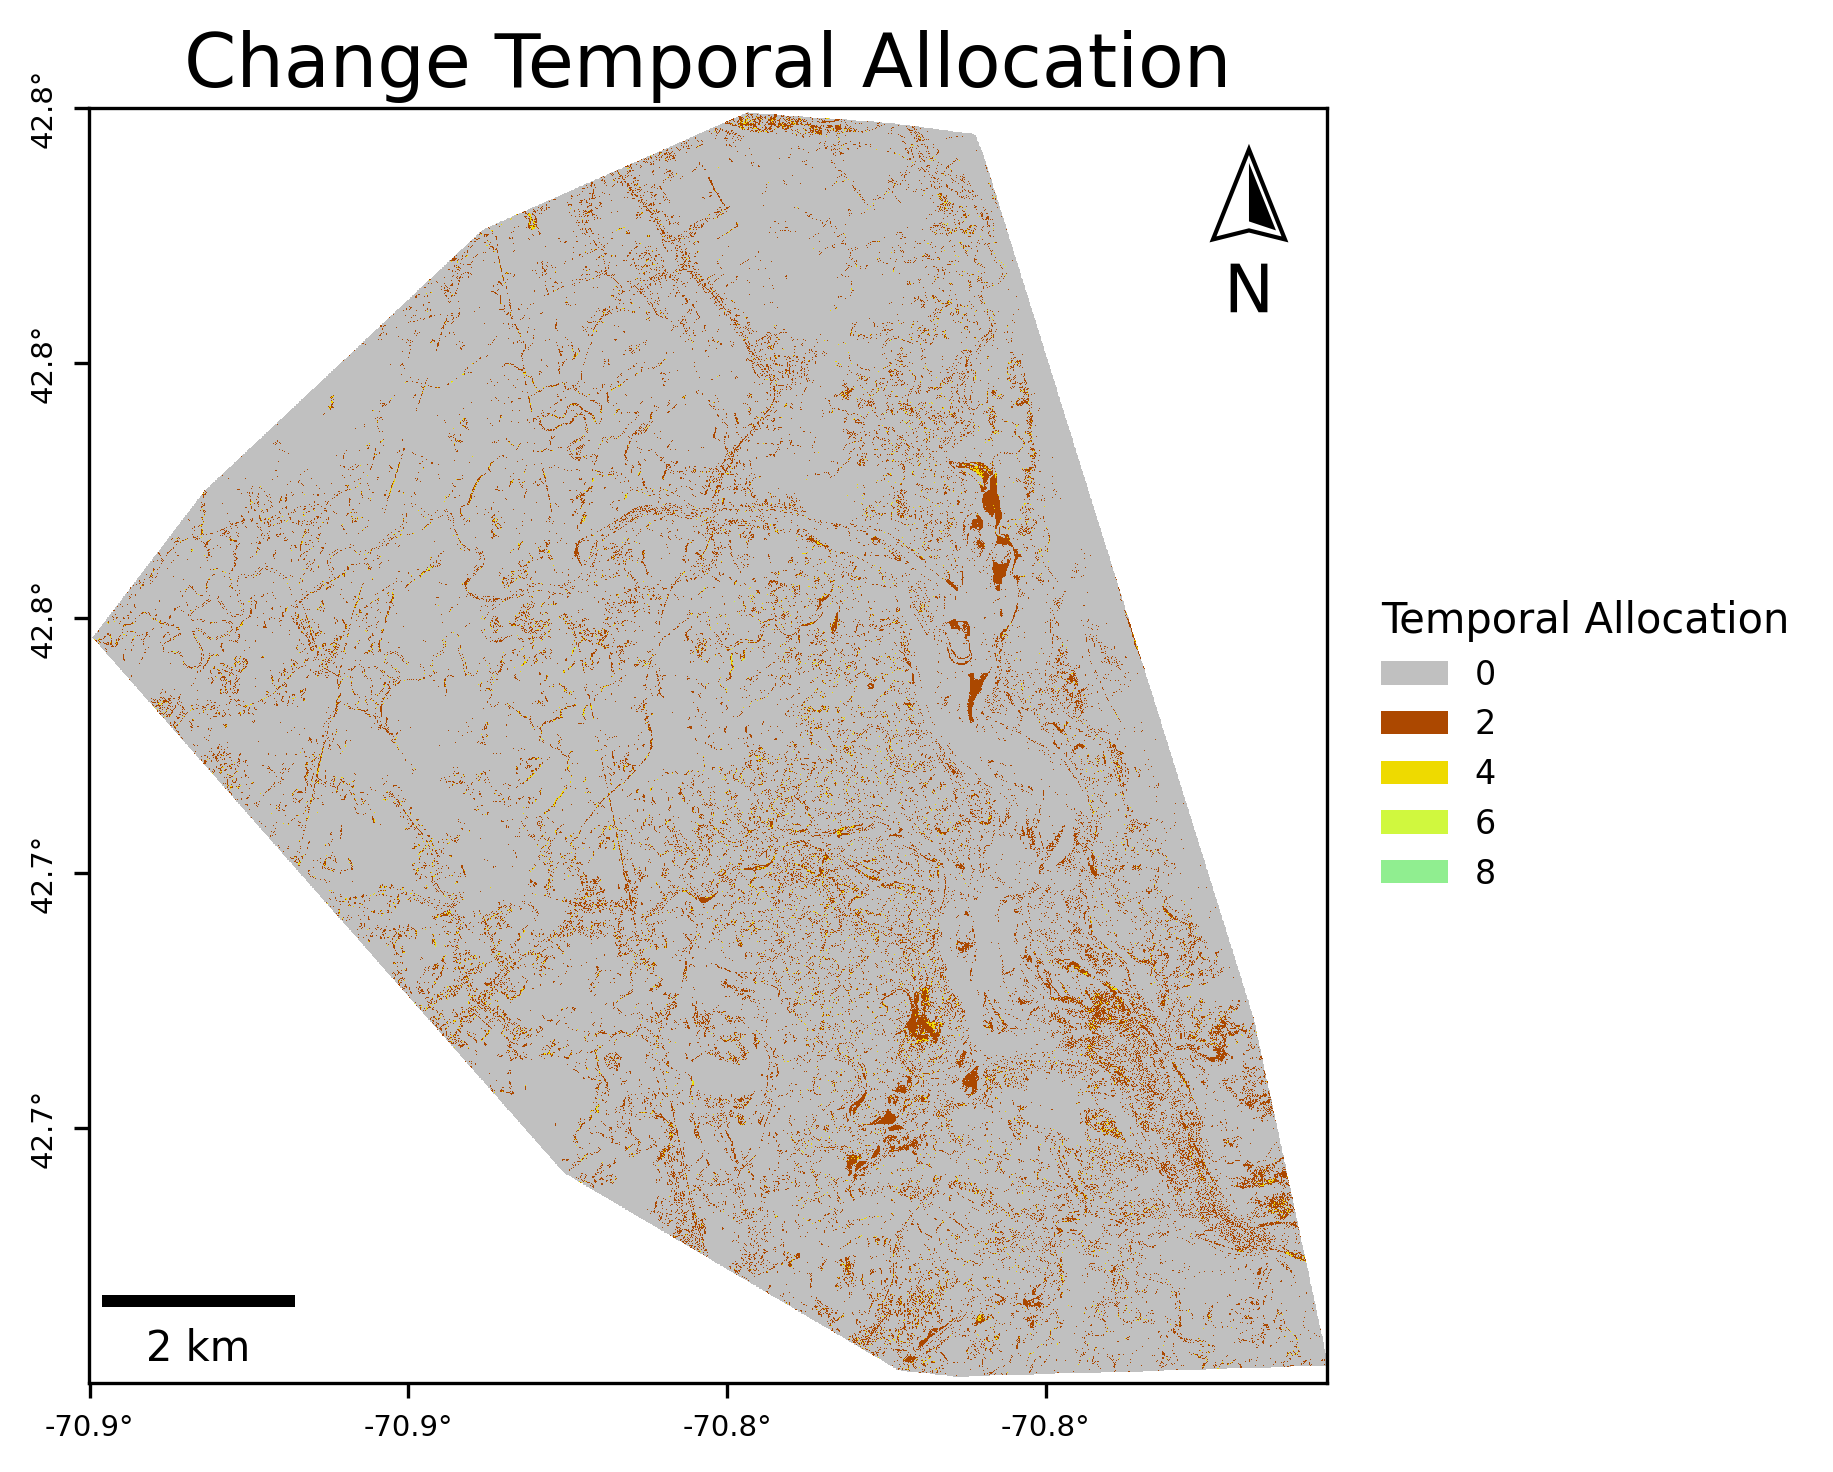

Map successfully saved to: /content/drive/MyDrive/Assessments/compare-time-series/extent2/maps/map_change_temporal_allocation.png


In [ ]:
#import os
#import gc
#import numpy as np
#import rasterio
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mticker
#from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
#from matplotlib.ticker import FuncFormatter
#from matplotlib.patches import Patch
#from matplotlib_scalebar.scalebar import ScaleBar
#from matplotlib_map_utils import north_arrow
#from pyproj import Transformer
# @title 5.2.2.3 Temporal Allocation of Change
def plot_change_temporal_allocation_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str = "change_map_F_temporal_allocation.tif",
    max_display_dim: int = 2000
) -> None:
    """
    Plot the Change Temporal Allocation map using a discrete integer scale.

    This function implements automatic downsampling to handle large raster
    extents, ensuring kernel stability. It visualizes the temporal
    disagreement using a custom Red-Yellow-Green gradient.

    Parameters
    ----------
    output_dir : str
        Directory where the 'rasters' and 'maps' folders are located.
    nodata_val : int
        Pixel value indicating no data.
    raster_filename : str, optional
        Filename of the raster to be plotted.
        Default is "change_map_F_temporal_allocation.tif".
    max_display_dim : int, optional
        Maximum dimension (width or height) in pixels for the display
        grid to optimize RAM usage. Default is 2000.

    Returns
    -------
    None
    """
    # 1. Path Setup
    rasters_dir = os.path.join(
        output_dir,
        "rasters"
    )
    raster_path = os.path.join(
        rasters_dir,
        raster_filename
    )

    if not os.path.exists(
        raster_path
    ):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}"
        )

    print(
        f"Reading Change Temporal Allocation map for plotting: {raster_path}"
    )

    # 2. Data Loading with Downsampling
    with rasterio.open(
        raster_path
    ) as src:
        # Calculate scale factor to stay under memory limits
        scale_factor = max_display_dim / max(
            src.width,
            src.height
        )

        if scale_factor > 1:
            scale_factor = 1.0

        out_shape = (
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        )

        print(
            f"Loading raster with downsampling factor: {scale_factor:.2f}"
        )

        # Read data with nearest neighbor to preserve integer allocation counts
        data = src.read(
            1,
            out_shape=out_shape,
            resampling=rasterio.enums.Resampling.nearest
        )

        # Update spatial transform to maintain coordinate and scale accuracy
        transform = src.transform * src.transform.scale(
            (src.width / data.shape[1]),
            (src.height / data.shape[0])
        )

        src_crs = src.crs
        data_masked = np.ma.masked_equal(
            data,
            nodata_val
        )

    # Compute pixel size for scale bar based on display resolution
    pixel_size_m = compute_display_pixel_size_m(
        raster_path=raster_path,
        downsample_divisor=int(1 / scale_factor) if scale_factor < 1 else 1
    )

    # 3. Colormap and Range Configuration
    data_max = int(
        data_masked.max()
    )

    # Safety bounds for indexing
    if data_max < 1:
        data_max = 1

    colors_dict = {
        0: "#c0c0c0"
    }

    # Custom gradient for positive values: Dark Red -> Yellow -> Light Green
    pos_cmap = LinearSegmentedColormap.from_list(
        "red_yellow_green",
        [
            "#8b0000",
            "#ffff00",
            "#90ee90"
        ]
    )

    for i, val in enumerate(
        range(1, data_max + 1)
    ):
        frac = i / (data_max - 1) if data_max > 1 else 0.5
        colors_dict[val] = pos_cmap(frac)

    # Build colormap from dict
    all_vals = np.arange(
        0,
        data_max + 1
    )
    colors_list = [
        colors_dict.get(v, "#000000") for v in all_vals
    ]
    cmap = ListedColormap(
        colors_list
    )

    # Boundaries for discrete integer steps
    bounds = np.arange(
        -0.5,
        data_max + 1.5,
        1
    )
    norm = BoundaryNorm(
        bounds,
        cmap.N
    )

    # 4. Plotting the Figure
    fig, ax = plt.subplots(
        figsize=(8, 5),
        dpi=300
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.05
    )

    im = ax.imshow(
        data_masked,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    # 5. Legend Configuration
    present_values = np.unique(
        data_masked.compressed()
    )
    present_values_sorted = np.sort(
        present_values
    )

    legend_elements = [
        Patch(
            facecolor=colors_dict.get(val, "#000"),
            edgecolor="none",
            label=str(val)
        ) for val in present_values_sorted
    ]

    ax.legend(
        handles=legend_elements,
        title="Temporal Allocation",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8,
        title_fontsize=10,
        alignment="left"
    )

    # 6. Cartographic Elements
    scalebar = ScaleBar(
        pixel_size_m,
        units="m",
        length_fraction=0.35,
        location="lower left",
        box_alpha=0.0
    )
    ax.add_artist(
        scalebar
    )

    north_arrow(
        ax,
        location="upper right",
        shadow=False,
        scale=0.3
    )

    # 7. Axes Styling and Coordinate Formatting
    ax.set_title(
        "Change Temporal Allocation",
        fontsize=18,
        pad=5
    )
    ax.set_aspect(
        "equal"
    )

    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    height, width = data.shape

    def format_lon(x, pos):
        x = np.clip(x, 0, width - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, height // 2, x)
        lon, _ = to_latlon.transform(x_proj, y_proj)
        return f"{lon:.1f}°"

    def format_lat(y, pos):
        y = np.clip(y, 0, height - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, y, width // 2)
        _, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lat:.1f}°"

    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    ax.tick_params(axis="both", labelsize=7, pad=4)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center")

    # 8. Output and Memory Cleanup
    maps_dir = os.path.join(output_dir, "maps")
    os.makedirs(maps_dir, exist_ok=True)
    output_figure_path = os.path.join(maps_dir, "map_change_temporal_allocation.png")

    plt.savefig(
        output_figure_path,
        dpi=300,
        format="png"
    )
    plt.show()

    print(f"Map successfully saved to: {output_figure_path}")

    # Explicitly clear memory
    del data
    del data_masked
    gc.collect()

# Execute the function
plot_change_temporal_allocation_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="change_map_F_temporal_allocation.tif"
)